In [1]:
import anndata as ad
from statsmodels.stats.multitest import multipletests 
import matplotlib
# import palantir
import scanpy as sc
from utils import *
from first_part import *
from adjustText import adjust_text
atac_input_file_name = "../../Cellformer/cellformer_PD/adata_deconvolution_PD_2024_trained_all_filtered_Nov24.h5ad"
outdir = "./outdir/"

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packag

In [2]:
##Load data
adata = sc.read_h5ad(atac_input_file_name)
adata = prepareData(adata)
adata

/Users/eloiseberson/code/PD-epigenomic-analysis/src/utils.py:104: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["condition2"] = adata.obs["condition"].replace({"LRRK2-PD-":"LRRK2", "LRRK2-PD+":"LRRK2"}).values


AnnData object with n_obs × n_vars = 2358 × 42352
    obs: 'celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch', 'PatientID', 'Unnamed: 0', 'Sample_id', 'Name', 'OldName', 'NewName', 'HarmonizedName', 'Bam', 'Contrast', 'Type', 'Group', 'Region', 'RegionMod', 'PatientIDMod', 'TypeMod', 'Cohort', 'TissueCenter', 'TypeGroup', 'xxx.TechRep', 'Batch', 'xxx.Sample', 'xxx.Library', 'xxx.BioRep', 'xxx.TechRep.1', 'Pool', 'xxx.race', 'Gender', 'age at death', 'PMI', 'Mutation', 'MutationType', 'xxx.last_mmse_test_score', 'ApoE', 'xxx.last_mmse_test_date', 'xxx.motor_updrs_score_on', 'xxx.motor_updrs_score_off', 'xxx.motor_updrs_score_months_prior_to_death', 'xxx.Control', 'xxx.AD', 'xxx.PD', 'xxx.DLB', 'xxx.VAD', 'xxx.PSP', 'xxx.HS', 'xxx.DLDH', 'xxx.MND', 'xxx.CBD', 'xxx.PICKS', 'xxx.HD', 'xxx.MSA', 'xxx.ARG', 'xxx.CWMR', 'xxx.dementia_nos', 'xxx.MS', 'xxx.CAA', 'xxx.MCI', 'xxx.LBS', 'xxx.BRAIN_ABNORMAL', 'xxx.ACUTE_INFARCTS', 'xxx.PlaqueF', 'xxx.PlaqueT', 'xxx.PlaqueP', 'xxx.

In [3]:
adata.obs.groupby(["condition","Sex"]).PatientID.nunique()

condition  Sex   
CTRL       Female     5
           Male      10
GBA1-PD+   Female     6
           Male       9
LRRK2-PD+  Female     1
           Male       2
SPOR       Female     3
           Male      12
Name: PatientID, dtype: int64

In [4]:
adata.obs['MutationType'].unique().tolist()

[nan,
 'N370S/N370S',
 'E326K',
 'T369M, V447E',
 'T369M',
 'L1114L',
 'N370S',
 'T369M, C342',
 'S196P',
 'H255Q',
 'L444P',
 'G2019S']

In [5]:
adata.obs["ApoE4"].unique()

array(['E4-', 'E4+'], dtype=object)

In [6]:
adata.obs[["condition", "PatientID",'age at death']].drop_duplicates().groupby("condition")['age at death'].std()

condition
CTRL         4.611580
GBA1-PD+     5.853774
LRRK2-PD+    4.358899
SPOR         5.755329
Name: age at death, dtype: float64

In [ ]:
#DE SPOR & GBA1 PD+
method = 'pydeseq2_sex_adjusted_no_refit_refined'
condition = "condition"
peaks_df = differential_expression(adata[adata.obs.condition.isin(["SPOR", "GBA1-PD+","LRRK2-PD+"])], 0,
                    method, corr_=["Sex"], columns=condition)
peaks_df
peaks_df.to_pickle("./res_DE_%s_%s.pickle"%(method,condition))

In [8]:
#Fixed adjusting pvalue problem and annotated significant CAR
method = 'pydeseq2_sex_adjusted_no_refit_refined'
condition = "condition"
res_DE_file_name = "./res_DE_%s_%s.pickle"%(method,condition)

outname = "de_corr"
res_DE = pd.read_pickle(res_DE_file_name)
res_DE.comparison.unique()


res_DE = compute_multitesting(res_DE) 
res_DE = filter_sig(res_DE,logFC = 0.5, pvalue=0.05)

#plot_DE(res_DE,outdir,outname)
# res_DE = res_DE[res_DE.comparison == "SPOR$GBA1"]


outname = "DE_%s_%s"%(method,condition)

90it [00:46,  1.92it/s]


In [9]:
res_DE

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,index,nearestGeneChip,nearestGene,peakType,...,names,-log10(pvals),-log10(qvals),ranks,significant,downreg,type_reg,comparison,br,ct
chr1_999876_1000376,2375.479226,0.170186,0.956519,0.177922,0.858784,0.999779,chr1_999876_1000376,HES4,HES4,Promoter,...,chr1_999876_1000376,0.066116,0.000096,0.000016,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1158074_1158574,14817.056471,0.053146,0.130974,0.405772,0.684910,0.999020,chr1_1158074_1158574,MIR200B,MIR200B,Distal,...,chr1_1158074_1158574,0.164366,0.000426,0.000023,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1298766_1299266,14089.219876,0.220837,0.191784,1.151484,0.249533,0.985958,chr1_1298766_1299266,ACAP3,MIR6726,Exonic,...,chr1_1298766_1299266,0.602872,0.006142,0.001356,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1357803_1358303,4306.486421,0.028785,0.312683,0.092058,0.926652,0.999884,chr1_1357803_1358303,MXRA8,MXRA8,Intronic,...,chr1_1357803_1358303,0.033083,0.000050,0.000001,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1360395_1360895,5261.147537,0.032358,0.220241,0.146919,0.883196,0.999884,chr1_1360395_1360895,MXRA8,MXRA8,Intronic,...,chr1_1360395_1360895,0.053943,0.000050,0.000002,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX_141969569_141970069,2881.517921,0.518080,0.249935,2.072862,0.038185,0.361803,chrX_141969569_141970069,LOC105373345,MAGEC1,Distal,...,chrX_141969569_141970069,1.418106,0.576419,0.298631,False,False,not significant,SPOR$All,SUNI,OLD
chrX_150291081_150291581,10947.287926,0.034002,0.133941,0.253858,0.799605,0.953363,chrX_150291081_150291581,MIR2114,MIR2114,Distal,...,chrX_150291081_150291581,0.097124,0.034555,0.001175,False,False,not significant,SPOR$All,SUNI,OLD
chrX_150465368_150465868,7551.669903,0.441533,0.150795,2.928026,0.003411,0.146766,chrX_150465368_150465868,MAMLD1,MTM1,Intronic,...,chrX_150465368_150465868,2.467091,1.002006,0.442418,False,False,not significant,SPOR$All,SUNI,OLD
chrX_153478652_153479152,3282.135493,0.193877,0.236070,0.821270,0.411493,0.819552,chrX_153478652_153479152,ECMXP,BGN,Intronic,...,chrX_153478652_153479152,0.385638,0.142189,0.027567,False,False,not significant,SPOR$All,SUNI,OLD


Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')


/Users/eloiseberson/code/PD-epigenomic-analysis/src/first_part.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


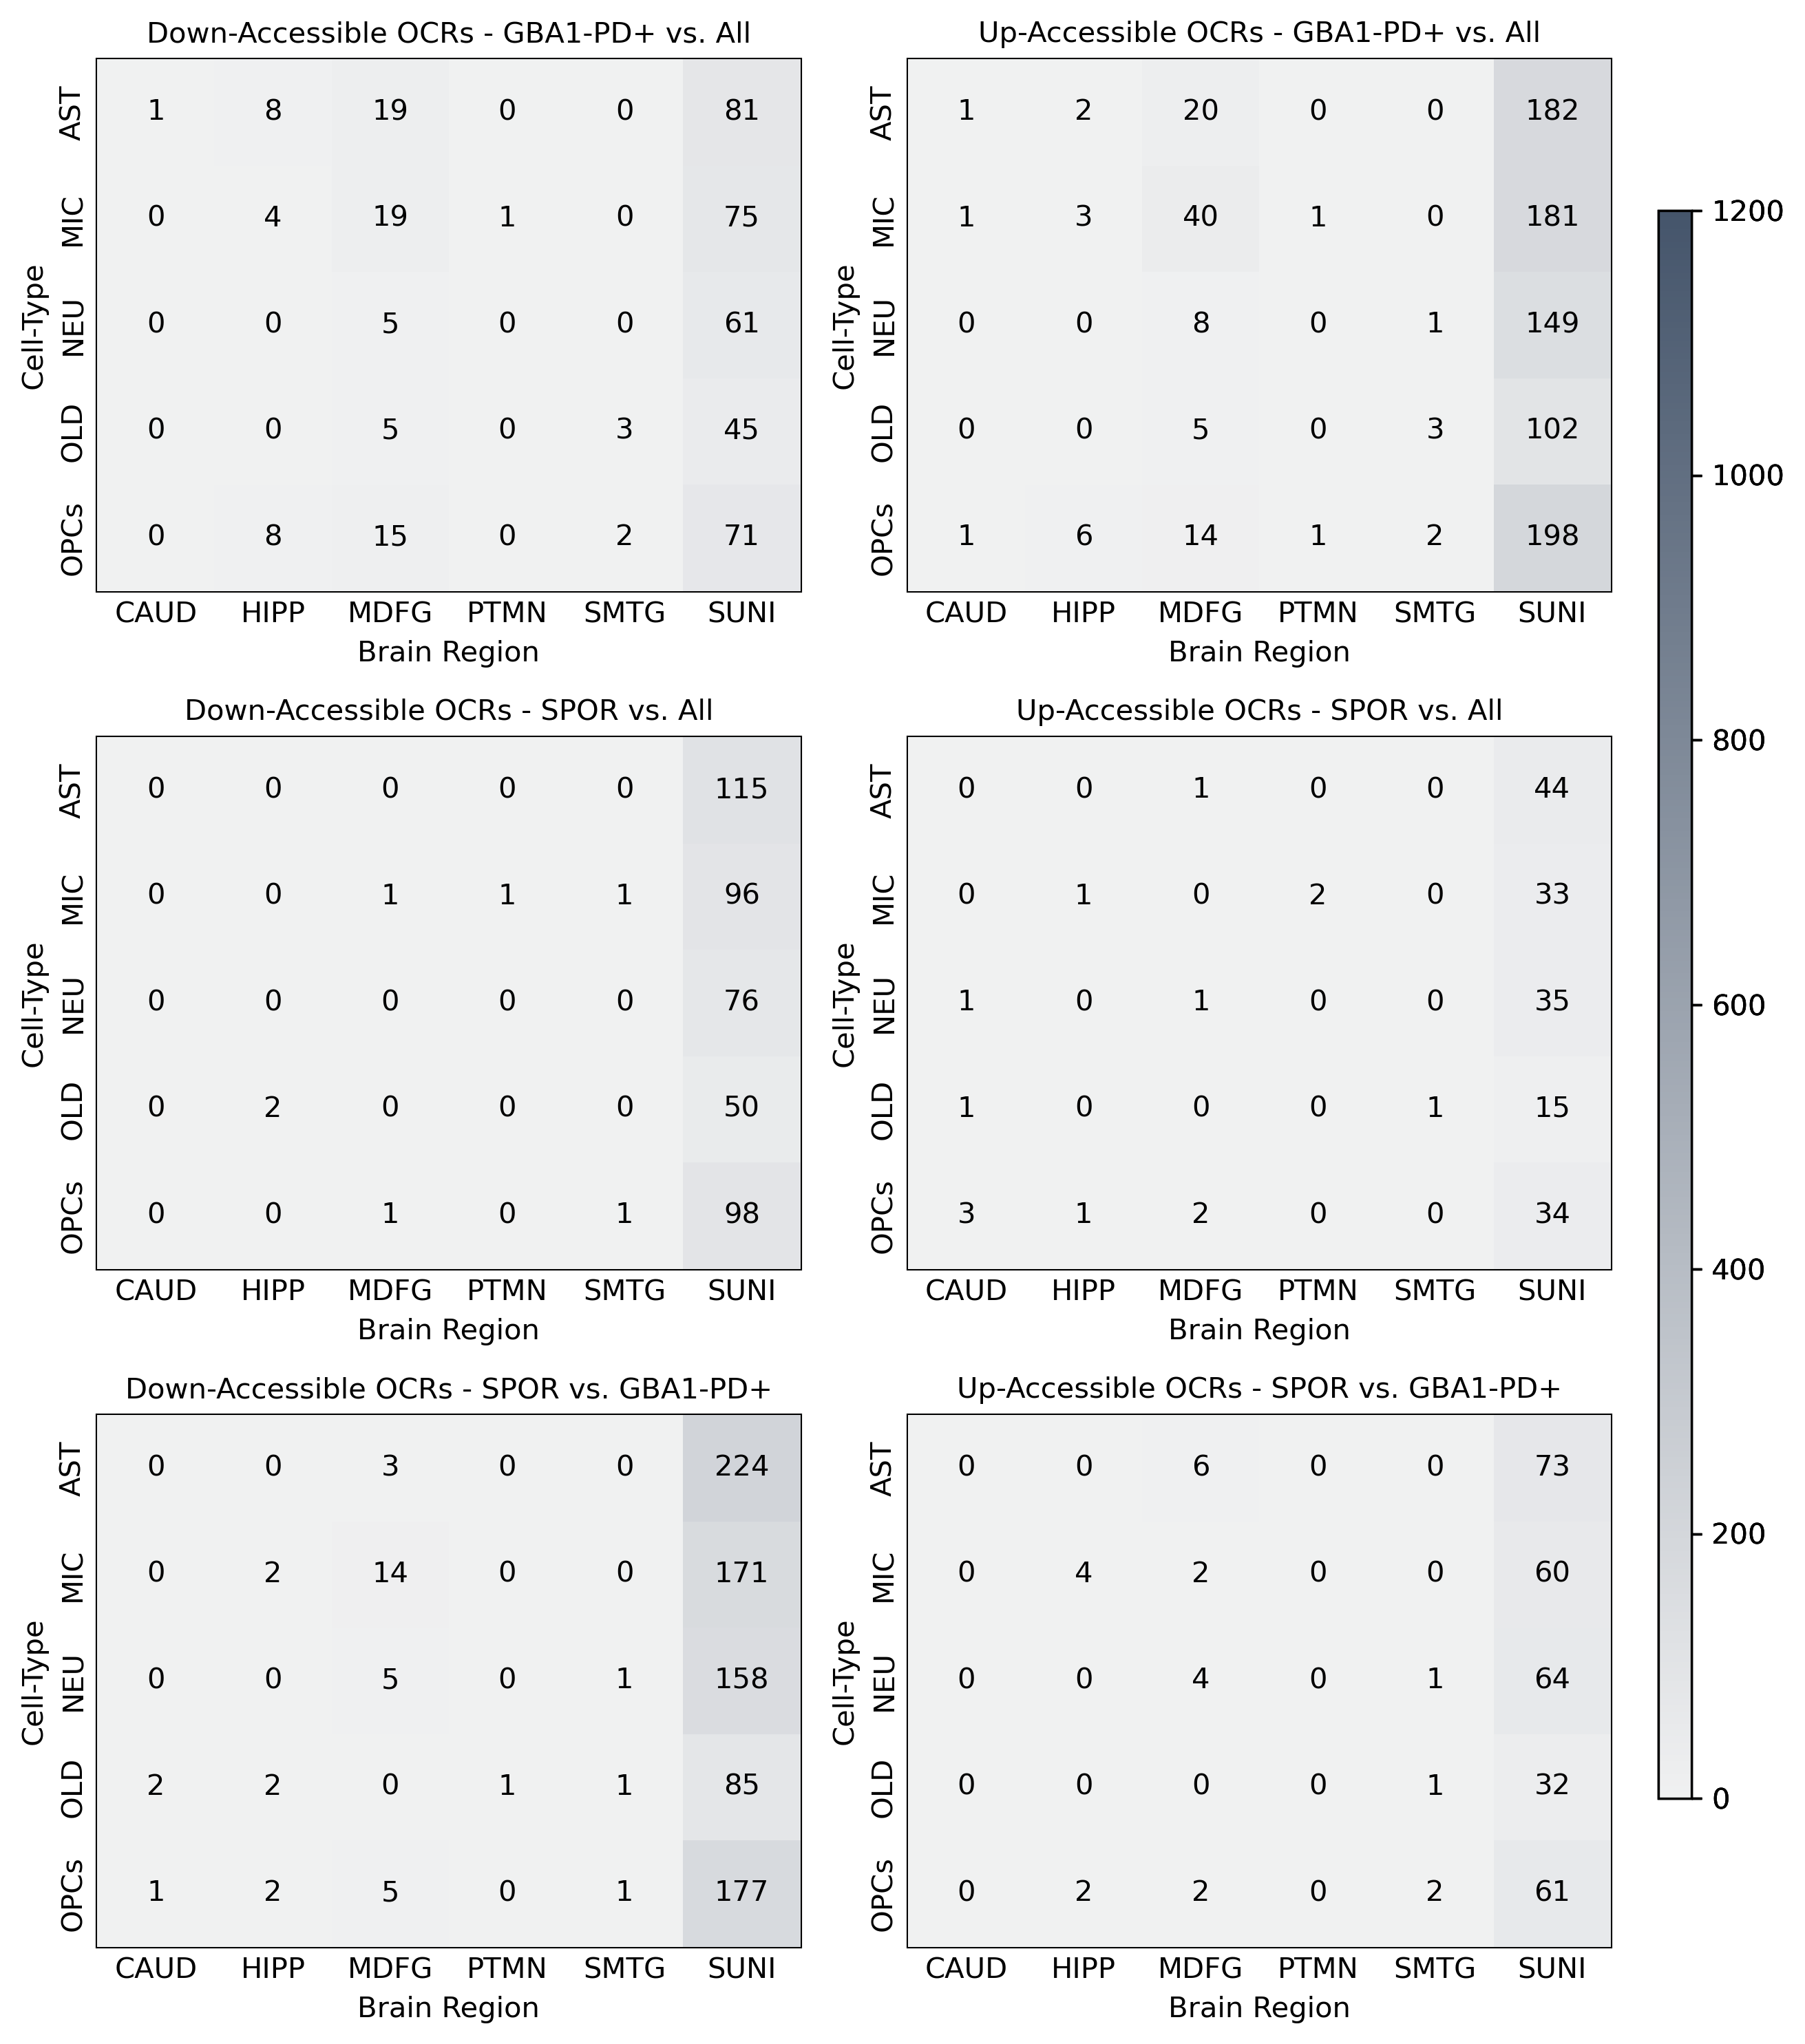

In [10]:
plot_DE_number(res_DE,outdir,outname, cmap=cmap)#,lf_key='log2FoldChange')


In [11]:
res_DE.comparison.unique()

array(['SPOR$GBA1-PD+', 'GBA1-PD+$All', 'SPOR$All'], dtype=object)

Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')


/Users/eloiseberson/code/PD-epigenomic-analysis/src/utils.py:416: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


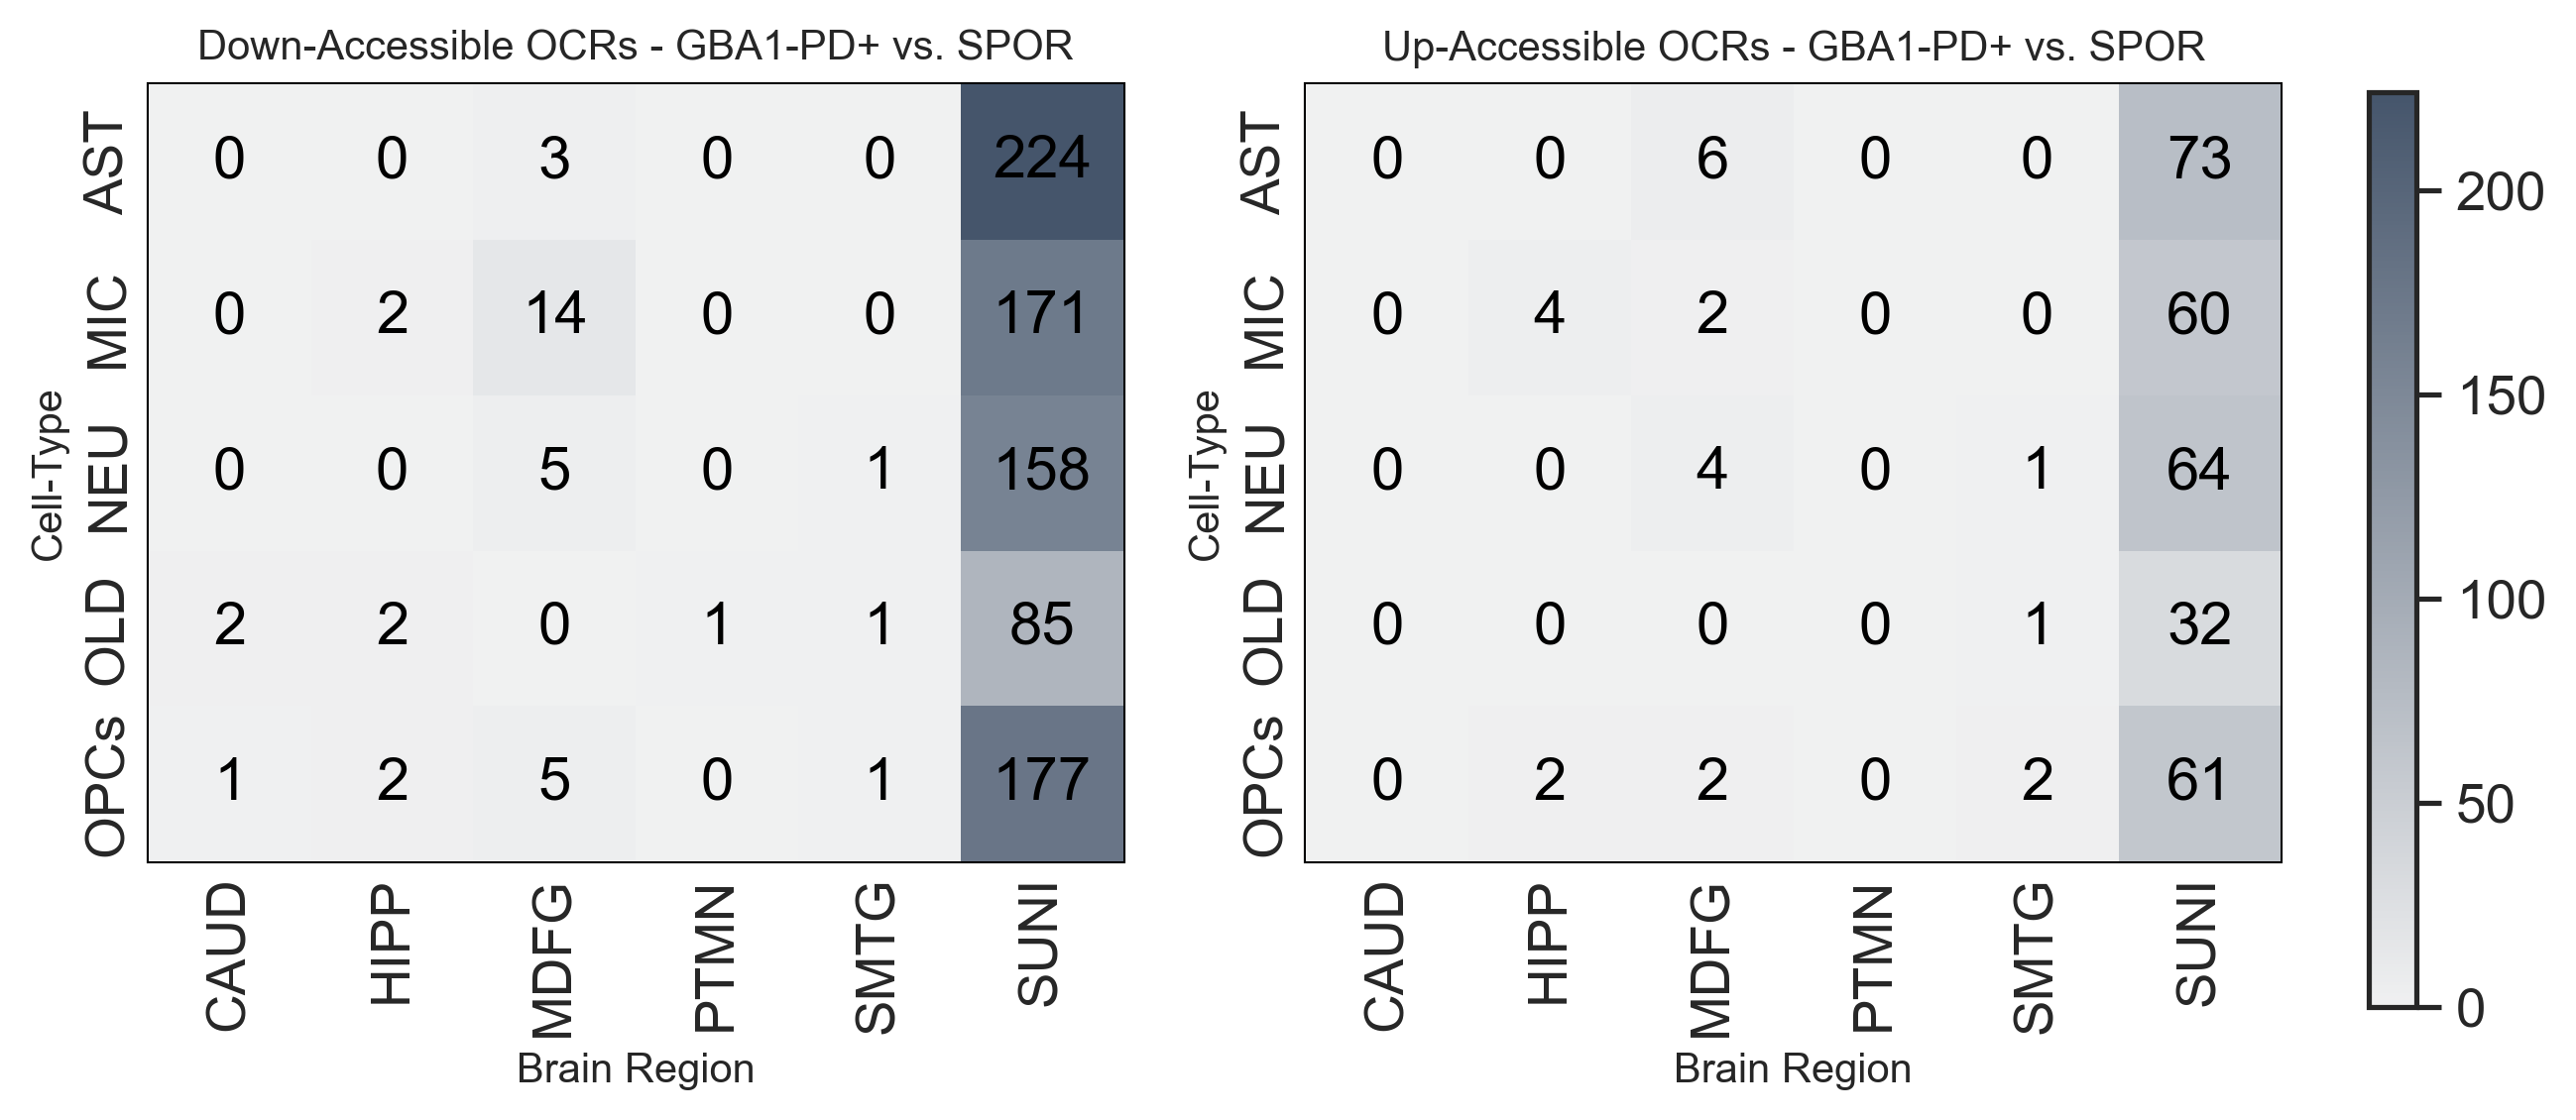

In [12]:

plot_DE_number_one(res_DE[res_DE.comparison=='SPOR$GBA1-PD+'],
                       outdir,outname,lf_key='log2FoldChange', 
                       cmap=cmap)

In [13]:
count = res_DE.loc[res_DE.significant==True,["comparison","br","ct"]].groupby(["br","ct","comparison"]).size().reset_index() #count()["log2FoldChange"].reset_index()

count = count.set_index(["br","ct","comparison"])
# all_possibilities = [(br,ct,downreg,comparison)
#                       for (br,ct,downreg,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["downreg"].unique(),res_DE["comparison"].unique()) ]

# count = count.set_index(["br","ct","comparison"])
all_possibilities = [(br,ct,comparison)
                      for (br,ct,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["comparison"].unique()) ]
    
for pos in all_possibilities:
        if pos not in count.index:
            count.loc[pos] = 0
    
count = count.reset_index()
# count["downreg"] = count["downreg"].replace({False:"Up regulated",True:"Down regulated"}).astype(str)

# count = count[(count.br=="SUNI") & (count.comparison.isin(["SPOR$GBA1-PD+", "SPOR$All" ,"GBA1-PD+$All"]))].drop("br", axis=1)
count = count[(count.br.isin(["SMTG","SUNI"]))]#.drop("br", axis=1)

df = pd.pivot_table(count, index=["br","comparison"], columns="ct", values=0)
print(df)
df["group"] = [it[0] for it in df.index.tolist()]
df = df.set_index("group")
df = df
df

ct                    AST    MIC    NEU    OLD   OPCs
br   comparison                                      
SMTG GBA1-PD+$All     0.0    0.0    1.0    6.0    4.0
     SPOR$All         0.0    1.0    0.0    1.0    1.0
     SPOR$GBA1-PD+    0.0    0.0    2.0    2.0    3.0
SUNI GBA1-PD+$All   263.0  256.0  210.0  147.0  269.0
     SPOR$All       159.0  129.0  111.0   65.0  132.0
     SPOR$GBA1-PD+  297.0  231.0  222.0  117.0  238.0


ct,AST,MIC,NEU,OLD,OPCs
group,,,,,
SMTG,0.0,0.0,1.0,6.0,4.0
SMTG,0.0,1.0,0.0,1.0,1.0
SMTG,0.0,0.0,2.0,2.0,3.0
SUNI,263.0,256.0,210.0,147.0,269.0
SUNI,159.0,129.0,111.0,65.0,132.0
SUNI,297.0,231.0,222.0,117.0,238.0


In [14]:
res_DE.loc[res_DE.significant==True,["comparison","br","ct"]].groupby(["br","ct","comparison"]).size()

br    ct    comparison   
CAUD  AST   GBA1-PD+$All       2
      MIC   GBA1-PD+$All       1
      NEU   SPOR$All           1
      OLD   SPOR$All           1
            SPOR$GBA1-PD+      2
      OPCs  GBA1-PD+$All       1
            SPOR$All           3
            SPOR$GBA1-PD+      1
HIPP  AST   GBA1-PD+$All      10
      MIC   GBA1-PD+$All       7
            SPOR$All           1
            SPOR$GBA1-PD+      6
      OLD   SPOR$All           2
            SPOR$GBA1-PD+      2
      OPCs  GBA1-PD+$All      14
            SPOR$All           1
            SPOR$GBA1-PD+      4
MDFG  AST   GBA1-PD+$All      39
            SPOR$All           1
            SPOR$GBA1-PD+      9
      MIC   GBA1-PD+$All      59
            SPOR$All           1
            SPOR$GBA1-PD+     16
      NEU   GBA1-PD+$All      13
            SPOR$All           1
            SPOR$GBA1-PD+      9
      OLD   GBA1-PD+$All      10
      OPCs  GBA1-PD+$All      29
            SPOR$All           3
            SPOR$

In [15]:
REGION = "SUNI"#"SUNI"
COMP=["SPOR$GBA1-PD+", "SPOR$All" ,"GBA1-PD+$All"]

count = res_DE[(res_DE.br==REGION) & (res_DE.comparison.isin(COMP))]

count = count.loc[count.significant==True,[ "comparison","br","ct"]].groupby(["br","ct","comparison"]).size().reset_index()
# count["downreg"] = count["downreg"].replace({False:"Up regulated",True:"Down regulated"})
count = count.set_index(["br","ct","comparison"])

all_possibilities = [(br,ct,comparison)
                      for (br,ct,comparison) in product([REGION],res_DE["ct"].unique(),[COMP]) ]
# print(all_possibilities)
to_add = [it for it in all_possibilities if it not in count.index.tolist()]
reverse = [it for it in  count.index.tolist() if it not in all_possibilities ]

# for pos in to_add:
#             count.loc[pos] = 0
# print(count)
count = count.reset_index()


count = count[(count.br==REGION) & (count.comparison.isin(COMP))].drop("br", axis=1)
print(count)
df = pd.pivot_table(count, index=["comparison"], columns="ct", values=0)
#df["group"] = [it[0]+"|"+it[1] for it in df.index.tolist()]
#df = df.set_index("group")
df

      ct     comparison    0
0    AST   GBA1-PD+$All  263
1    AST       SPOR$All  159
2    AST  SPOR$GBA1-PD+  297
3    MIC   GBA1-PD+$All  256
4    MIC       SPOR$All  129
5    MIC  SPOR$GBA1-PD+  231
6    NEU   GBA1-PD+$All  210
7    NEU       SPOR$All  111
8    NEU  SPOR$GBA1-PD+  222
9    OLD   GBA1-PD+$All  147
10   OLD       SPOR$All   65
11   OLD  SPOR$GBA1-PD+  117
12  OPCs   GBA1-PD+$All  269
13  OPCs       SPOR$All  132
14  OPCs  SPOR$GBA1-PD+  238


ct,AST,MIC,NEU,OLD,OPCs
comparison,,,,,
GBA1-PD+$All,263.0,256.0,210.0,147.0,269.0
SPOR$All,159.0,129.0,111.0,65.0,132.0
SPOR$GBA1-PD+,297.0,231.0,222.0,117.0,238.0


In [16]:
count = res_DE.loc[res_DE.significant==True,["comparison","br","ct"]].groupby(["br","ct","comparison"]).size().reset_index() #count()["log2FoldChange"].reset_index()

count = count.set_index(["br","ct","comparison"])
# all_possibilities = [(br,ct,downreg,comparison)
#                       for (br,ct,downreg,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["downreg"].unique(),res_DE["comparison"].unique()) ]

# count = count.set_index(["br","ct","comparison"])
all_possibilities = [(br,ct,comparison)
                      for (br,ct,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["comparison"].unique()) ]
    
for pos in all_possibilities:
        if pos not in count.index:
            count.loc[pos] = 0
    
count = count.reset_index()
# count["downreg"] = count["downreg"].replace({False:"Up regulated",True:"Down regulated"}).astype(str)

# count = count[(count.br=="SUNI") & (count.comparison.isin(["SPOR$GBA1-PD+", "SPOR$All" ,"GBA1-PD+$All"]))].drop("br", axis=1)
count = count#[(count.br.isin(["HIPP"]))]#.drop("br", axis=1)

df = pd.pivot_table(count, index=["br","comparison"], columns="ct", values=0)
print(df)
df["group"] = [it[0] for it in df.index.tolist()]
df = df.set_index("group")
df = df
df

ct                    AST    MIC    NEU    OLD   OPCs
br   comparison                                      
CAUD GBA1-PD+$All     2.0    1.0    0.0    0.0    1.0
     SPOR$All         0.0    0.0    1.0    1.0    3.0
     SPOR$GBA1-PD+    0.0    0.0    0.0    2.0    1.0
HIPP GBA1-PD+$All    10.0    7.0    0.0    0.0   14.0
     SPOR$All         0.0    1.0    0.0    2.0    1.0
     SPOR$GBA1-PD+    0.0    6.0    0.0    2.0    4.0
MDFG GBA1-PD+$All    39.0   59.0   13.0   10.0   29.0
     SPOR$All         1.0    1.0    1.0    0.0    3.0
     SPOR$GBA1-PD+    9.0   16.0    9.0    0.0    7.0
PTMN GBA1-PD+$All     0.0    2.0    0.0    0.0    1.0
     SPOR$All         0.0    3.0    0.0    0.0    0.0
     SPOR$GBA1-PD+    0.0    0.0    0.0    1.0    0.0
SMTG GBA1-PD+$All     0.0    0.0    1.0    6.0    4.0
     SPOR$All         0.0    1.0    0.0    1.0    1.0
     SPOR$GBA1-PD+    0.0    0.0    2.0    2.0    3.0
SUNI GBA1-PD+$All   263.0  256.0  210.0  147.0  269.0
     SPOR$All       159.0  1

ct,AST,MIC,NEU,OLD,OPCs
group,,,,,
CAUD,2.0,1.0,0.0,0.0,1.0
CAUD,0.0,0.0,1.0,1.0,3.0
CAUD,0.0,0.0,0.0,2.0,1.0
HIPP,10.0,7.0,0.0,0.0,14.0
HIPP,0.0,1.0,0.0,2.0,1.0
HIPP,0.0,6.0,0.0,2.0,4.0
MDFG,39.0,59.0,13.0,10.0,29.0
MDFG,1.0,1.0,1.0,0.0,3.0
MDFG,9.0,16.0,9.0,0.0,7.0


In [17]:
# plot_DE_number(res_DE,outdir,outname)#,lf_key='log2FoldChange')

Text(0, 0.0, 'CAUD')
Text(0, 1.0, 'HIPP')
Text(0, 2.0, 'MDFG')
Text(0, 3.0, 'SMTG')
Text(0, 4.0, 'SUNI')


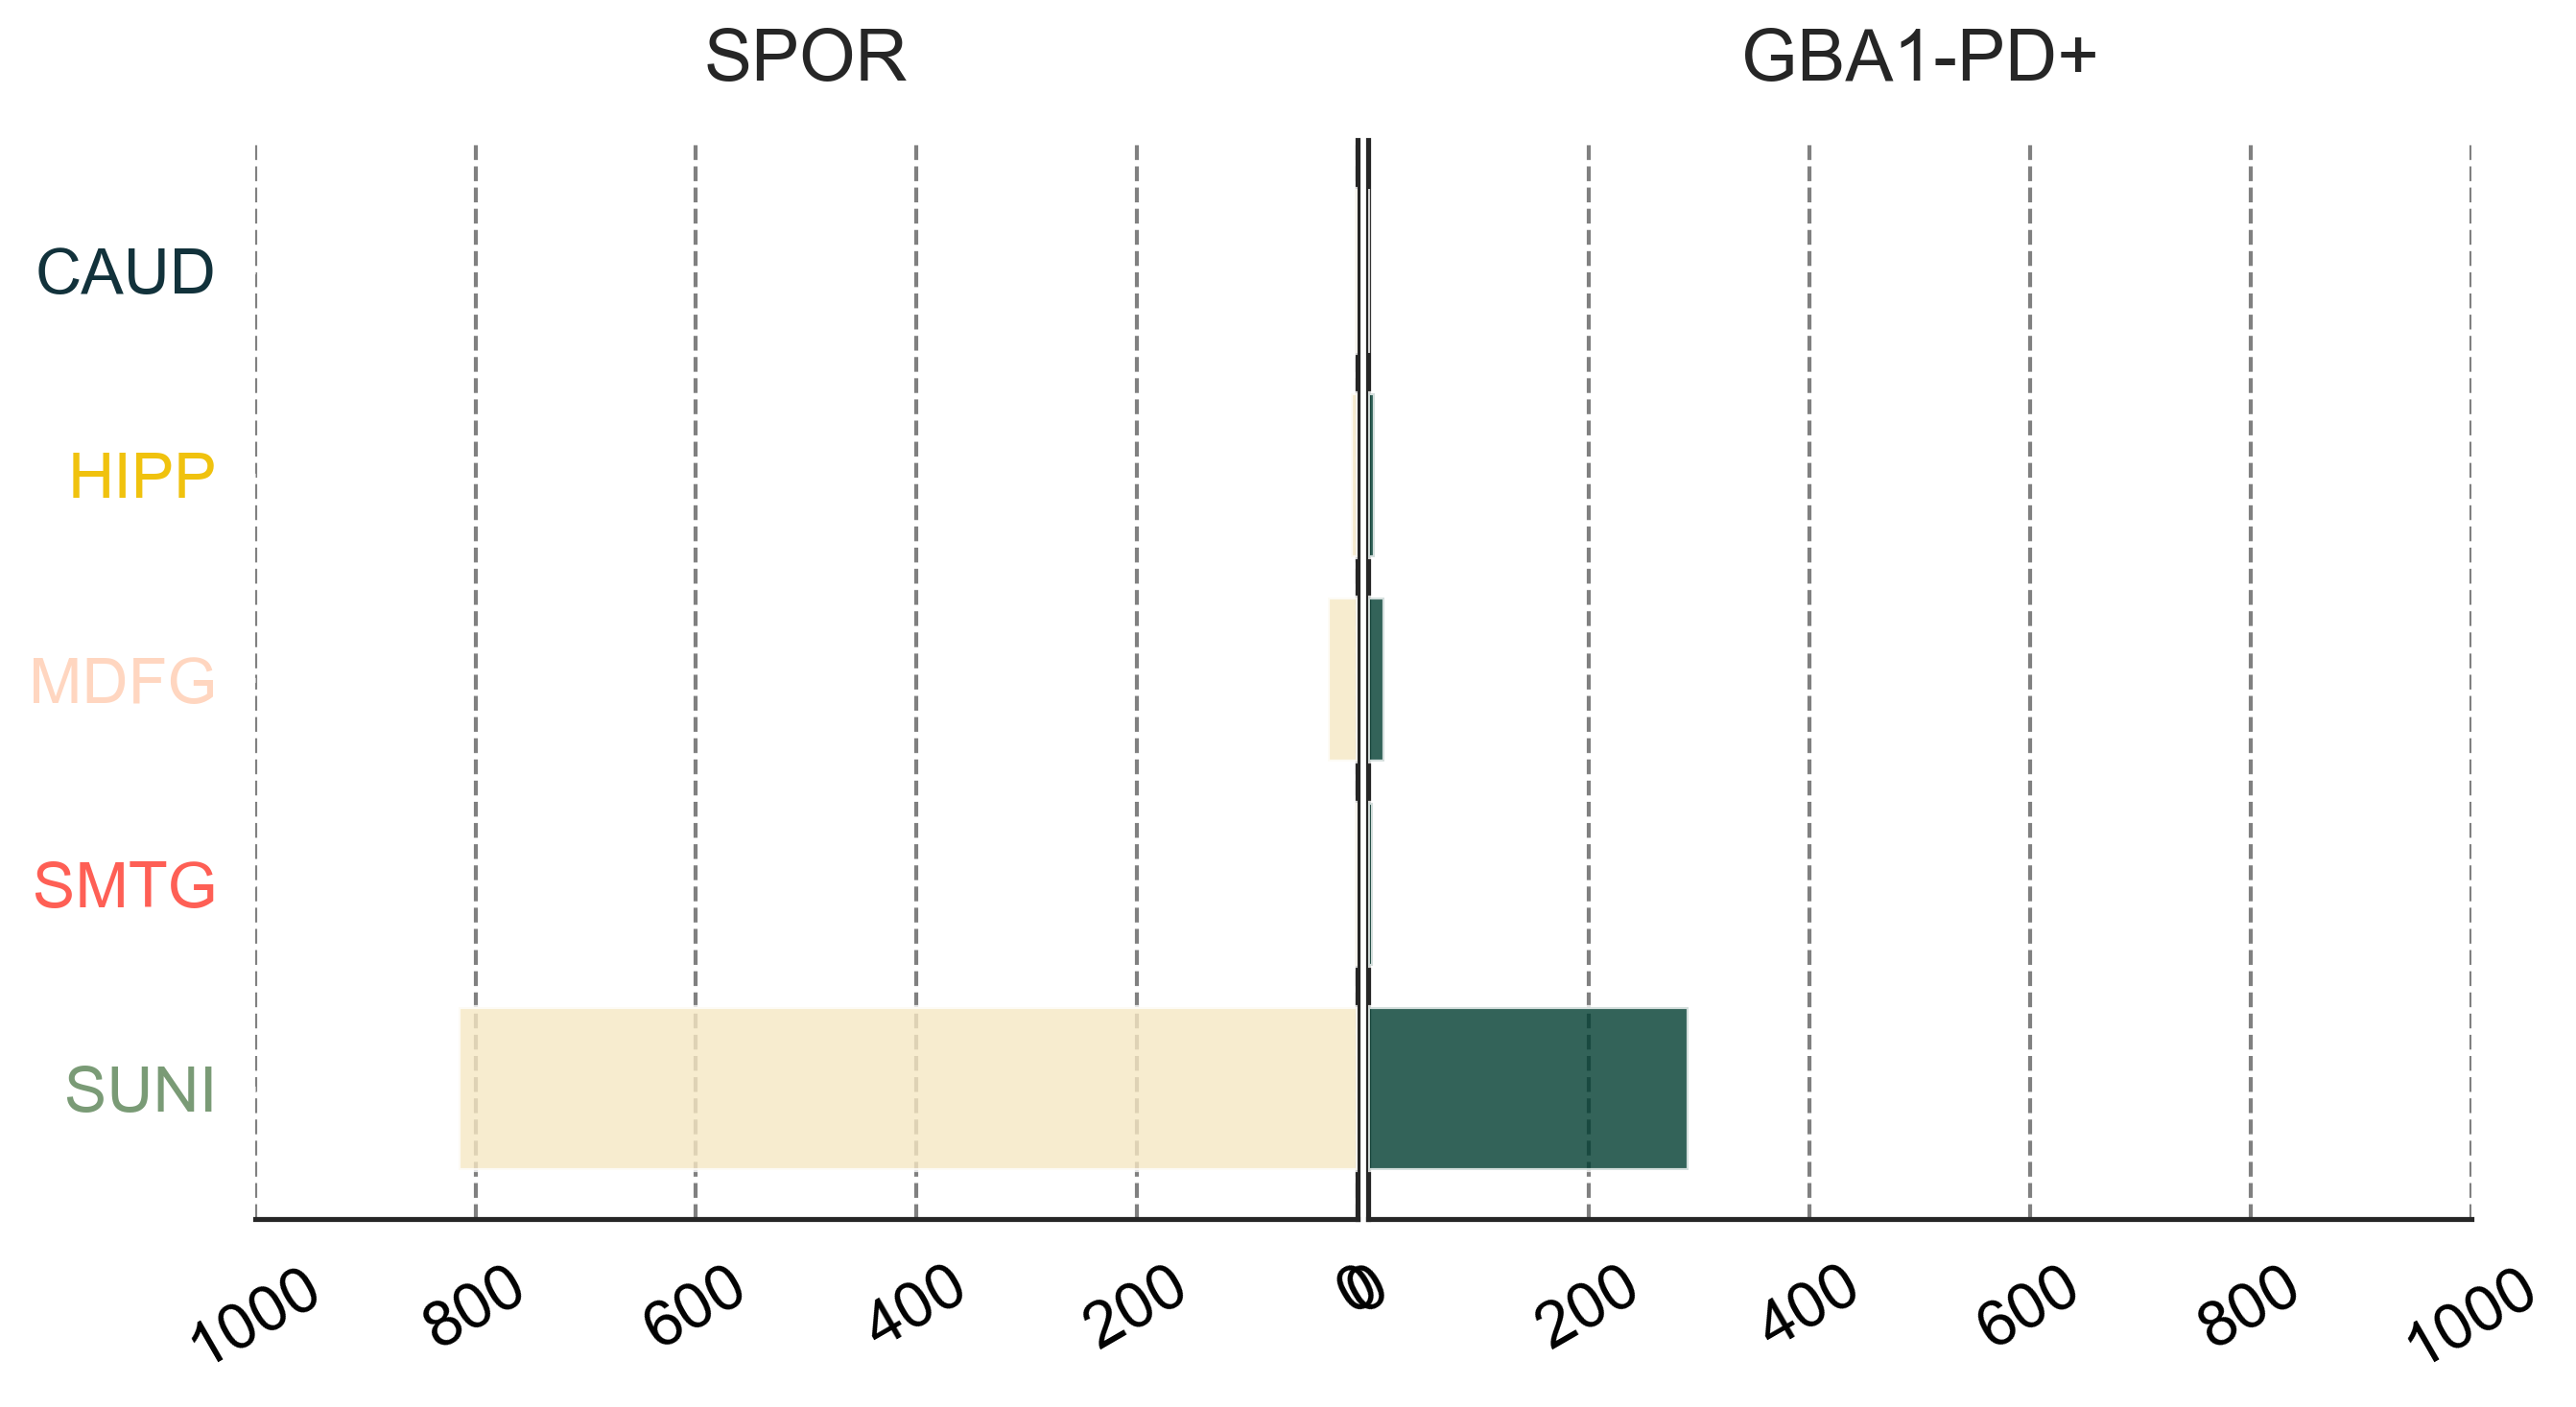

Text(0, 0.0, 'CAUD')
Text(0, 1.0, 'HIPP')
Text(0, 2.0, 'MDFG')
Text(0, 3.0, 'SMTG')
Text(0, 4.0, 'SUNI')


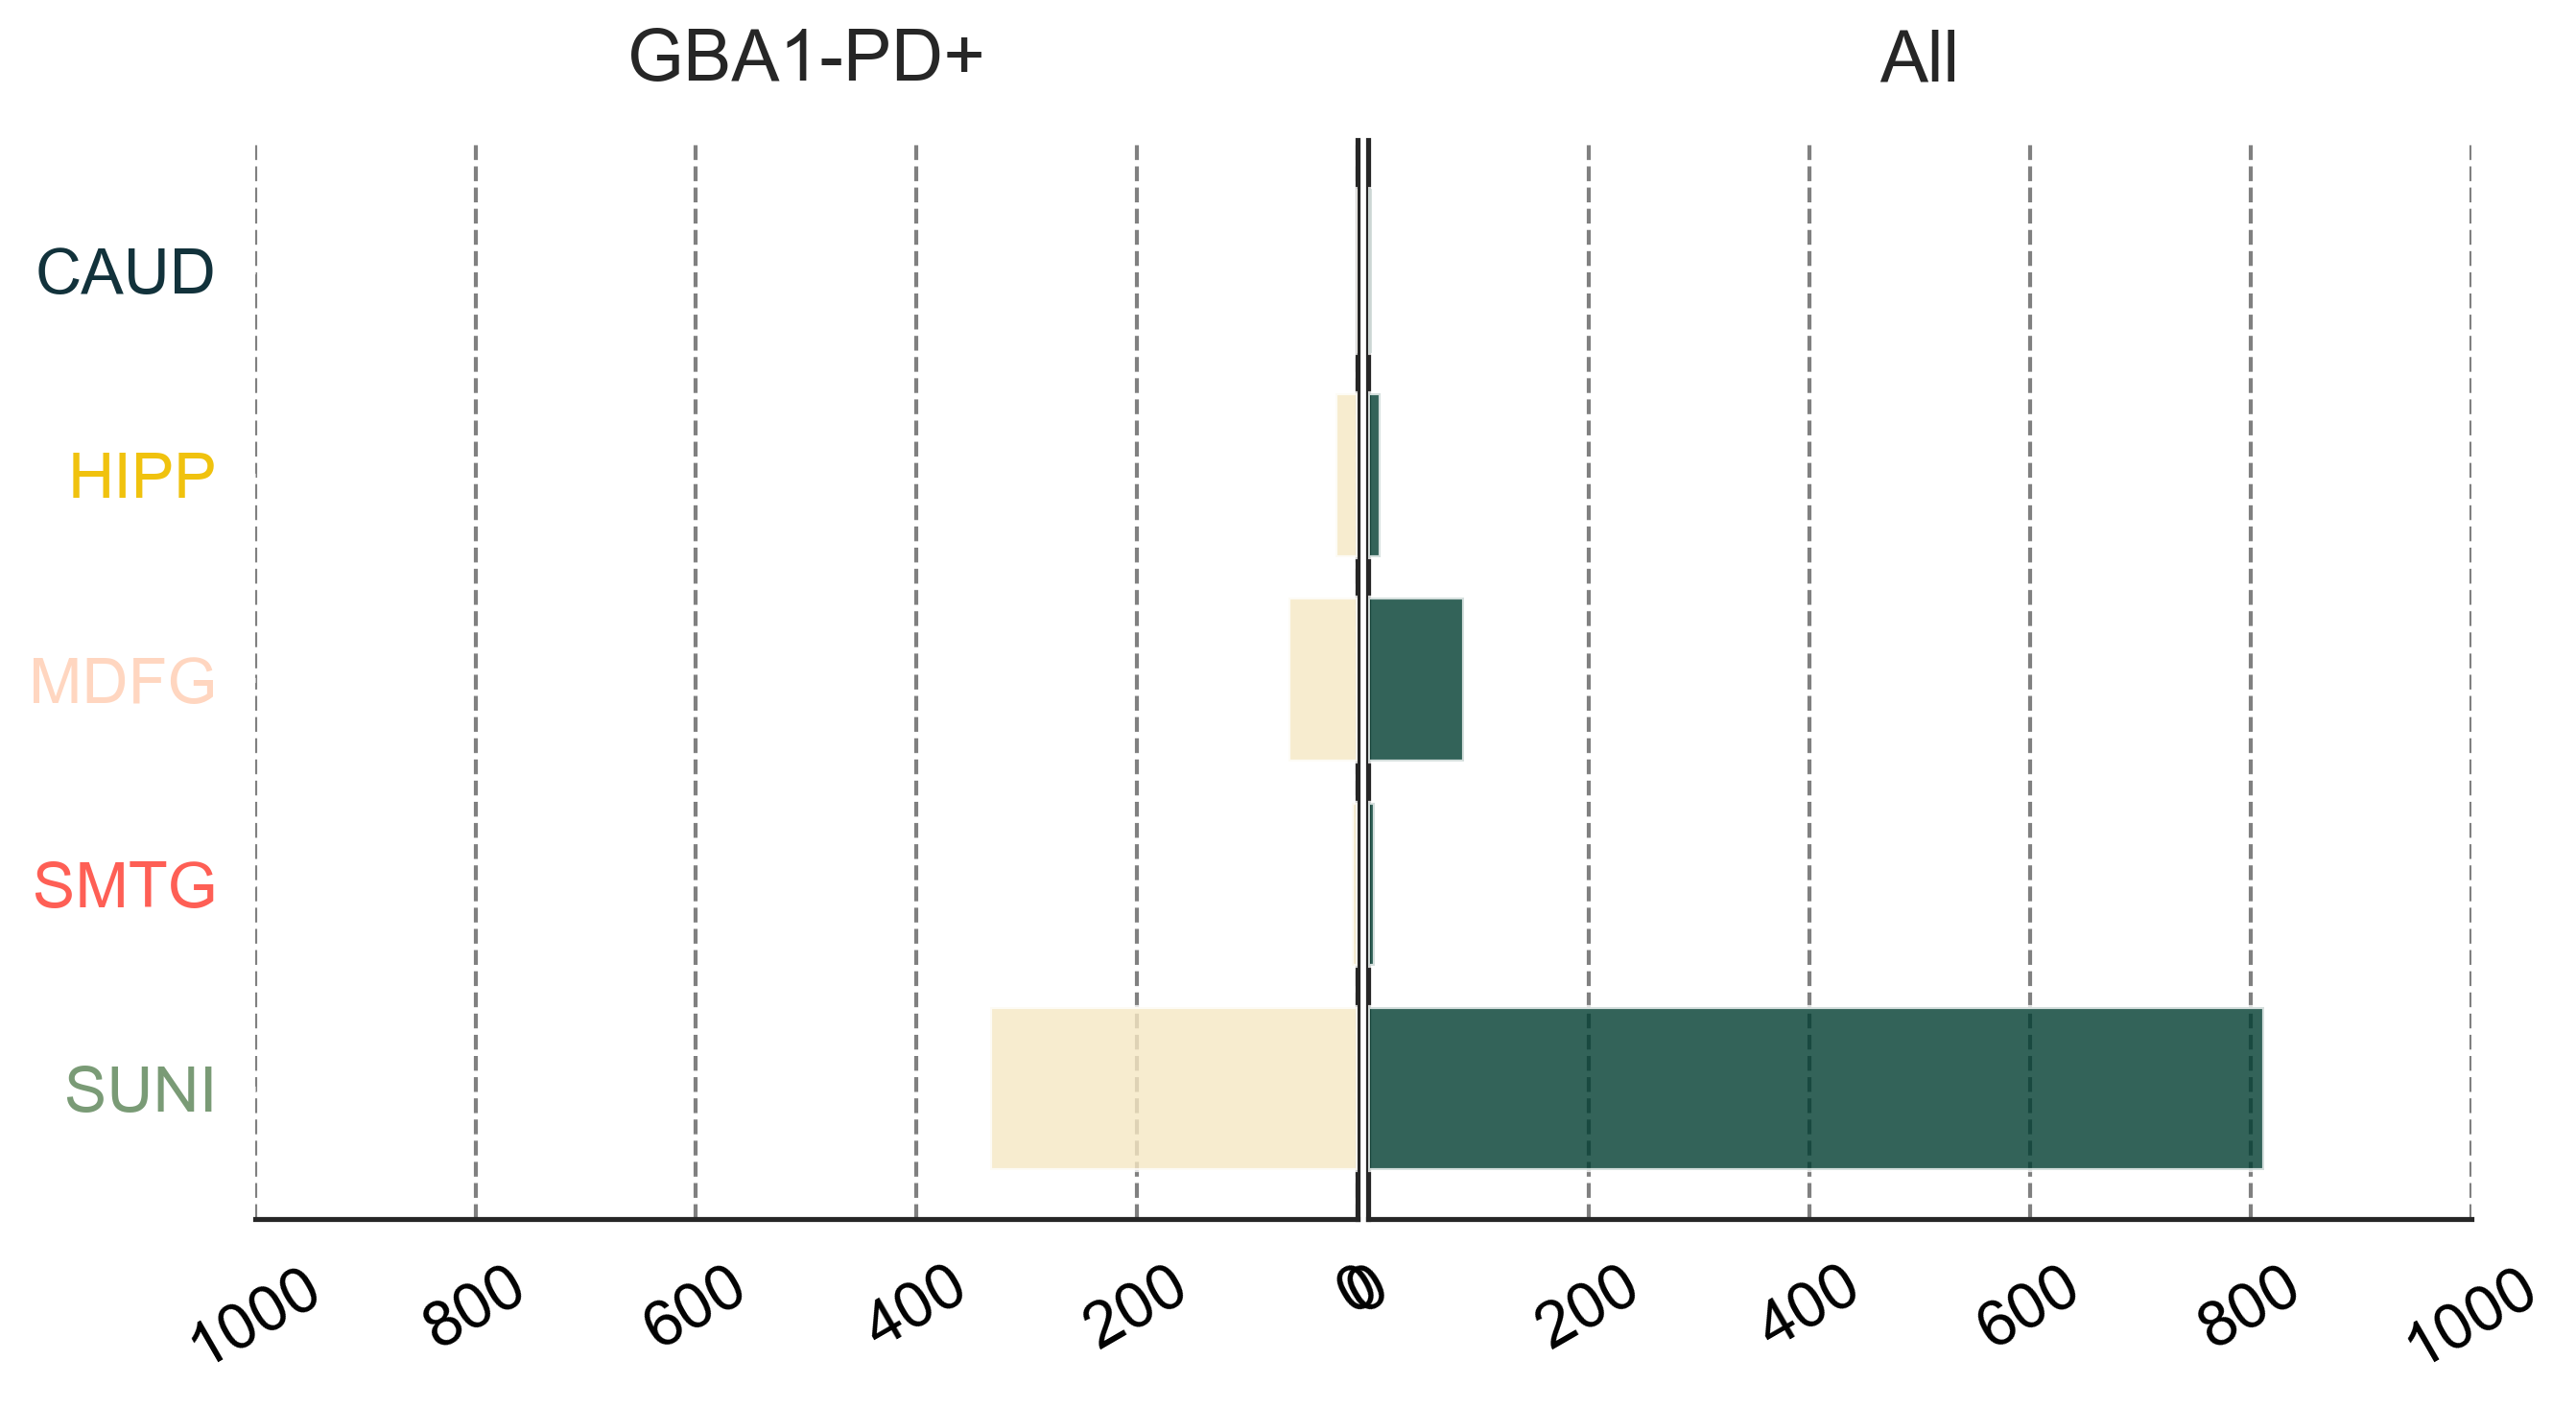

Text(0, 0.0, 'CAUD')
Text(0, 1.0, 'HIPP')
Text(0, 2.0, 'MDFG')
Text(0, 3.0, 'SMTG')
Text(0, 4.0, 'SUNI')


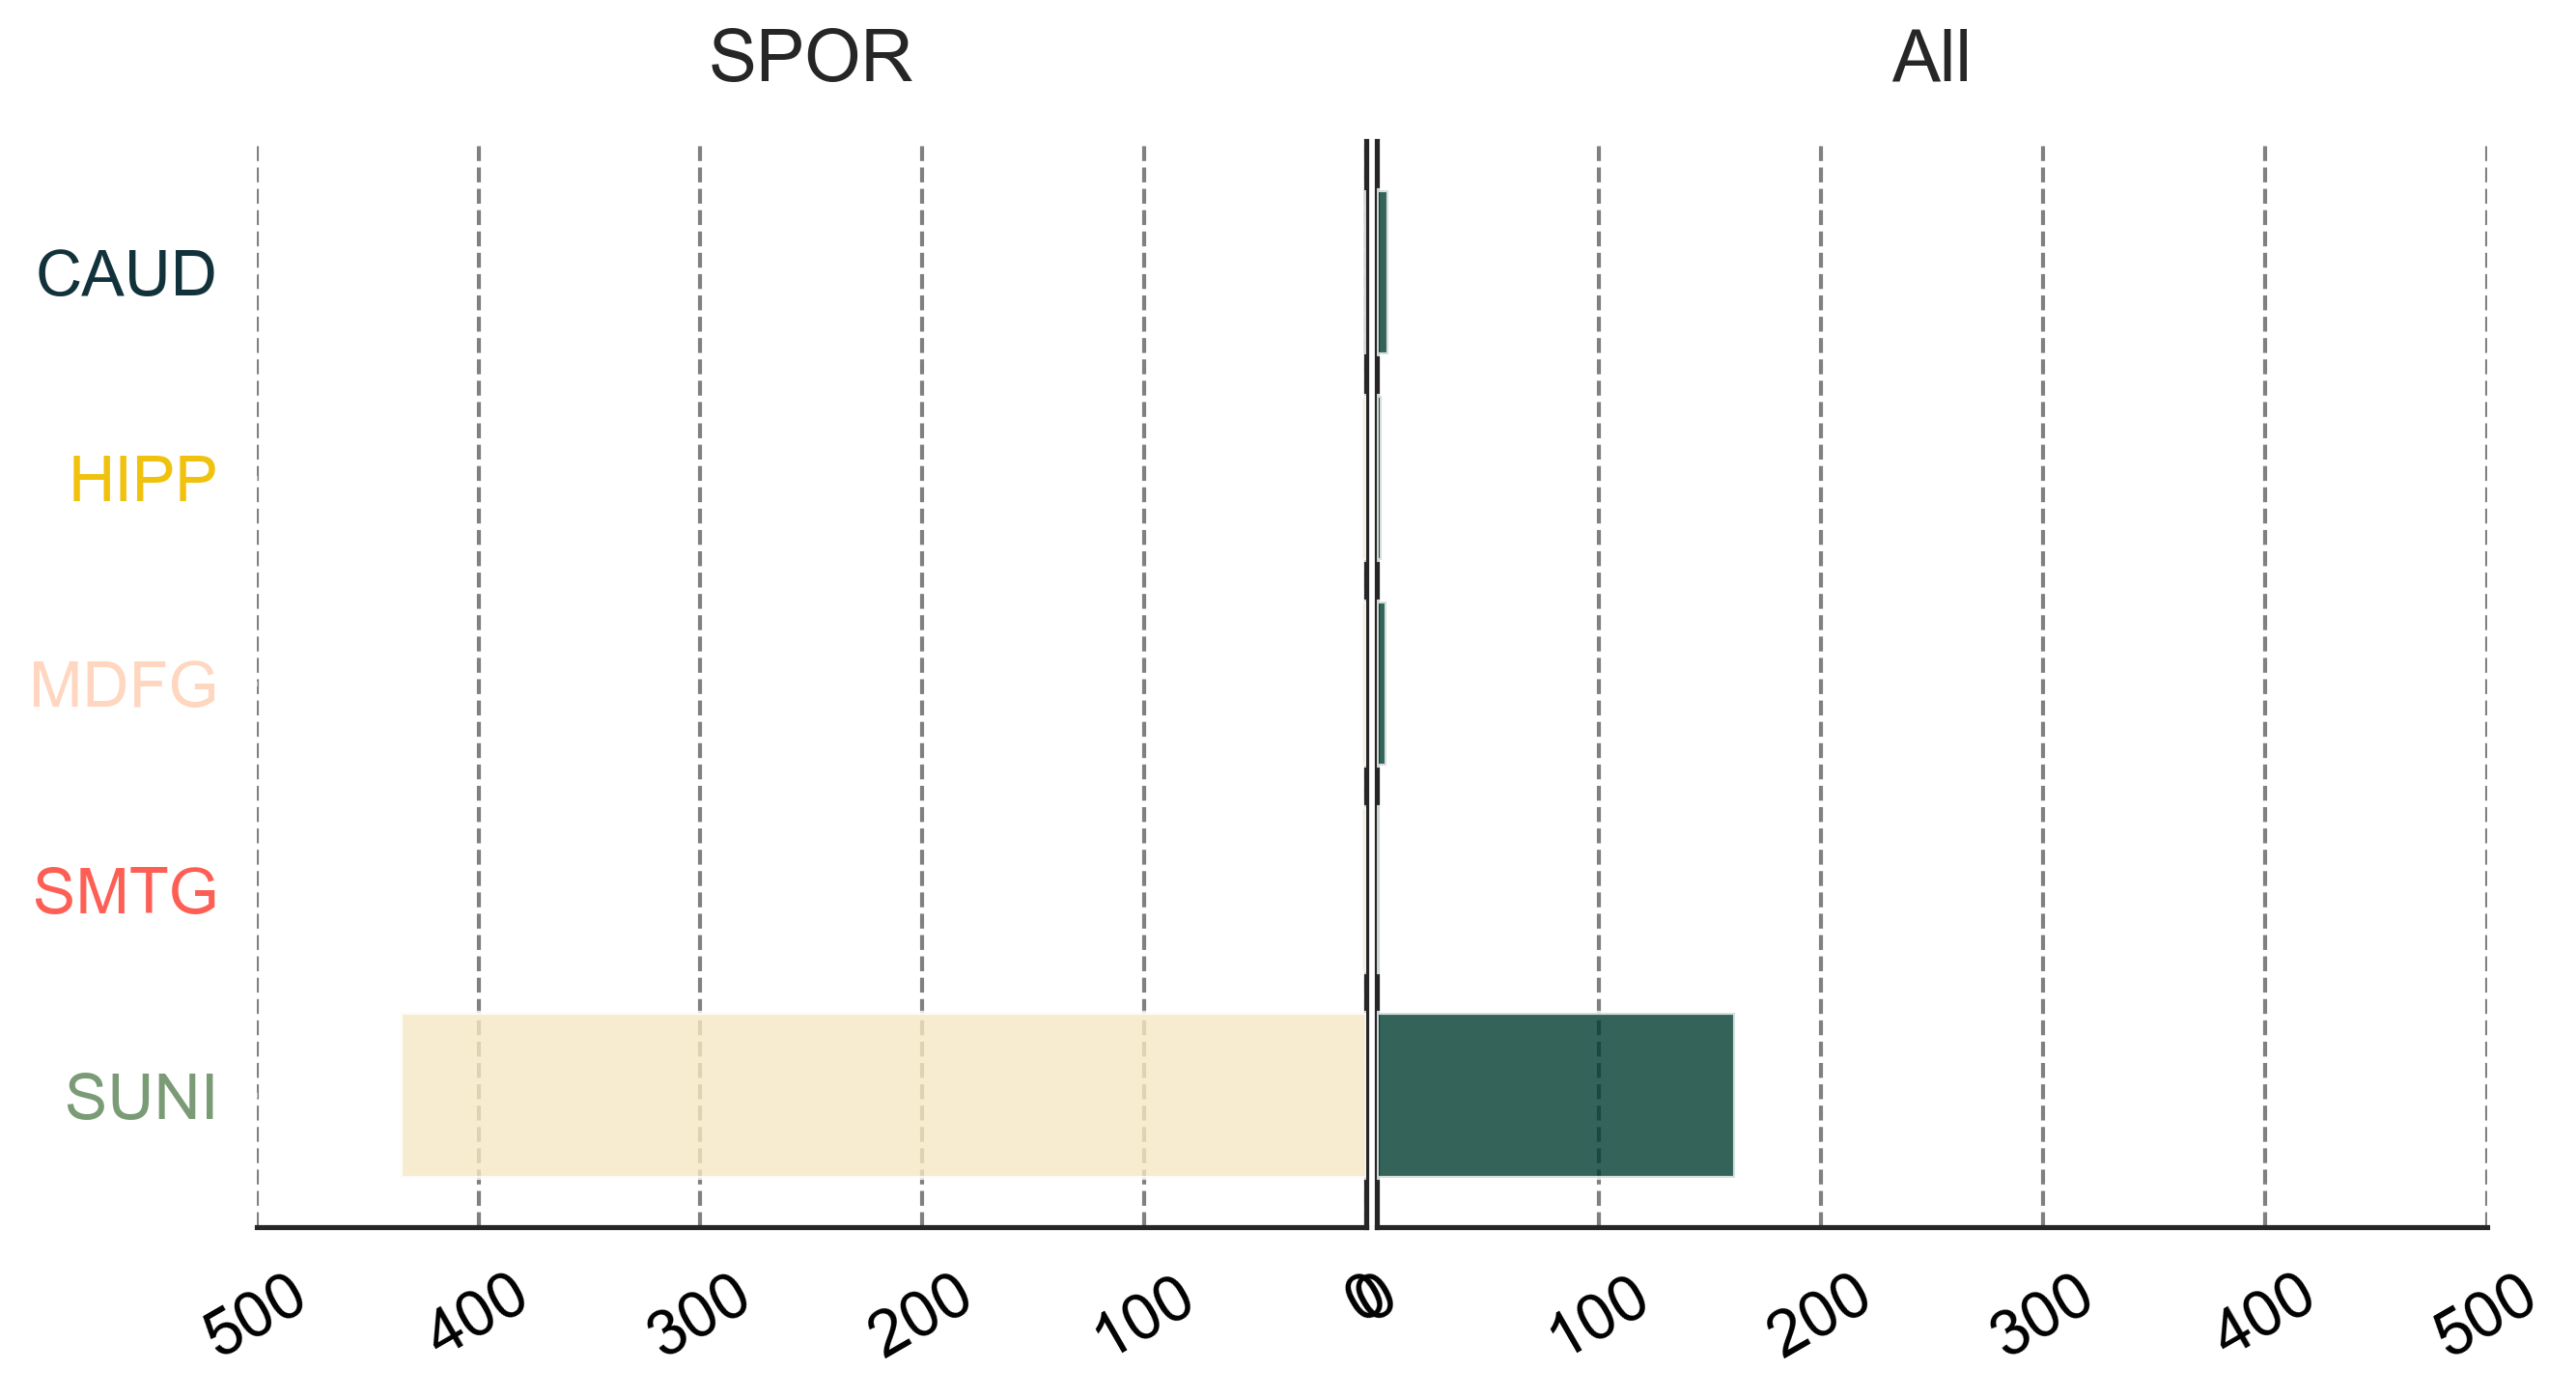

In [18]:
comp = "SPOR$GBA1/PD+/AD+"
comp = "GBA1/PD+/AD-$GBA1/PD+/AD+"
comp = "SPOR$GBA1-PD+"

region = ["CAUD","HIPP","MDFG",  "SMTG", "SUNI"]#"PTMN",

if condition=="ApoE4":
    region = ["CAUD","MDFG", "PTMN", "SMTG", "SUNI"]
for comp in res_DE.comparison.unique():
    cond1, cond2 = comp.split("$")
    de = res_DE[(res_DE.type_reg!="not significant") & (res_DE.comparison ==comp ) ]
    
    
    to_plot = pd.DataFrame(index=de.br.unique().tolist())
    to_plot =to_plot.loc[region,:]
    up = de[de["type_reg"]=="up"]
    up = pd.DataFrame(up.groupby("br").size(),#/len(up),
                      columns=["up"])
    to_plot = to_plot.join(up).fillna(0)
    up = de[de["type_reg"]=="down"]
    up = pd.DataFrame(up.groupby("br").size(),#/len(up),
                      columns=["down"])
    to_plot = to_plot.join(up).fillna(0)
    
    # to_plot = to_plot.sort_values("up", ascending=False)
    palette= {"up": "#4dac26", "down":"#d01c8b"}
    palette= {"down": "#F6E8C3", "up":"#003C30"}
    fig, axes = plt.subplots(figsize=(10,5), ncols=2, sharey=True)
    fig.tight_layout()
    
    brain_regions = to_plot.index.tolist()
    
    left1 = len(to_plot) * [0]
    left2 = len(to_plot) * [0]
    index = to_plot.index#.map('|'.join)
    # for idx, name in enumerate(brain_regions):
    axes[0].barh(index, to_plot["down"], left = left1, color=palette["down"],zorder=10, align="center", alpha=0.8)#, fill=False)
    axes[1].barh(index, to_plot["up"], left = left2, color=palette["up"],zorder=10, align="center", alpha=0.8)#, fill=False)
        # left1 = left1 + down[name]
        # left2 = left2 + up[name]
    
    axes[0].set_title(cond1, fontsize=18, pad=15)
    axes[1].set_title(cond2, fontsize=18, pad=15)
    
                
    # If you have positive numbers and want to invert the x-axis of the left plot
    axes[0].invert_xaxis() 
    
    # To show data from highest to lowest
    plt.gca().invert_yaxis()
        
    axes[0].set(yticks=brain_regions, yticklabels=brain_regions)
    axes[0].yaxis.tick_left()
    axes[0].tick_params(axis='y', colors='white') # tick color
    
    axes[1].spines['right'].set_visible(False)
    axes[0].spines['left'].set_visible(False)
    axes[0].spines['top'].set_visible(False)
    axes[1].spines['top'].set_visible(False)
    
    
    font_color = 'black'
    tmp = []
    for label in (axes[0].get_xticklabels()):
        label.set(fontsize=16, color=font_color, rotation=30)
    for label in (axes[1].get_xticklabels()):
        label.set(fontsize=16, color=font_color, rotation=30)
    for label in (axes[0].get_yticklabels()):
        print(label)
        txt = label.get_text()#.split("|")[1]
    
        cond = label.get_text()#.split("|")[0]
        tmp.append(cond)
        label.set(color=COLORS_CT[cond], label=str(txt), fontsize=16 )
    
    # labels = [item.get_text() for item in axes[0].get_yticklabels()]
    
    axes[1].yaxis.set_ticks_position('none') 
    # adjust limits and draw grid lines
    # plt.ylim(-0.5, ax.get_yticks()[-1] + 0.5)
    axes[0].set_axisbelow(True)
    axes[0].xaxis.grid(color='gray', linestyle='dashed')
    axes[1].set_axisbelow(True)
    axes[1].xaxis.grid(color='gray', linestyle='dashed')
    
    max_x = max(max(axes[0].get_xticks()),max(axes[1].get_xticks()))
    axes[0].set_xlim(max_x,0)
    axes[1].set_xlim(0,max_x)
    plt.subplots_adjust(wspace=0.01, top=0.85, bottom=0.1, left=0.18, right=0.95)
    # plt.suptitle("Porportion of cell type-specific DAR", fontsize=18)
    # leg1 = plt.legend(brain_regions, bbox_to_anchor=([0.99, 1, 0, 0]), ncol=4, frameon=False)
    # ll = []
    # for it in list(set(tmp)):
    #     blue_line = lines.Line2D([], [], color=color_cond[it], 
    #                                         marker="o",
    #                                         linestyle='None',
    #                                         markersize=8, label=it)
    #     ll.append(blue_line)
    # leg2 = plt.legend(handles=ll, bbox_to_anchor=(1.5, 0.25))
    
    # axes[1].add_artist(leg1)
    
    plt.savefig("./outdir/DE_OCR__%s"%comp.replace("/","-") + ".svg", bbox_inches="tight")
    plt.show()

Text(0, 0, 'AST')
Text(0, 1, 'MIC')
Text(0, 2, 'NEU')
Text(0, 3, 'OLD')
Text(0, 4, 'OPCs')


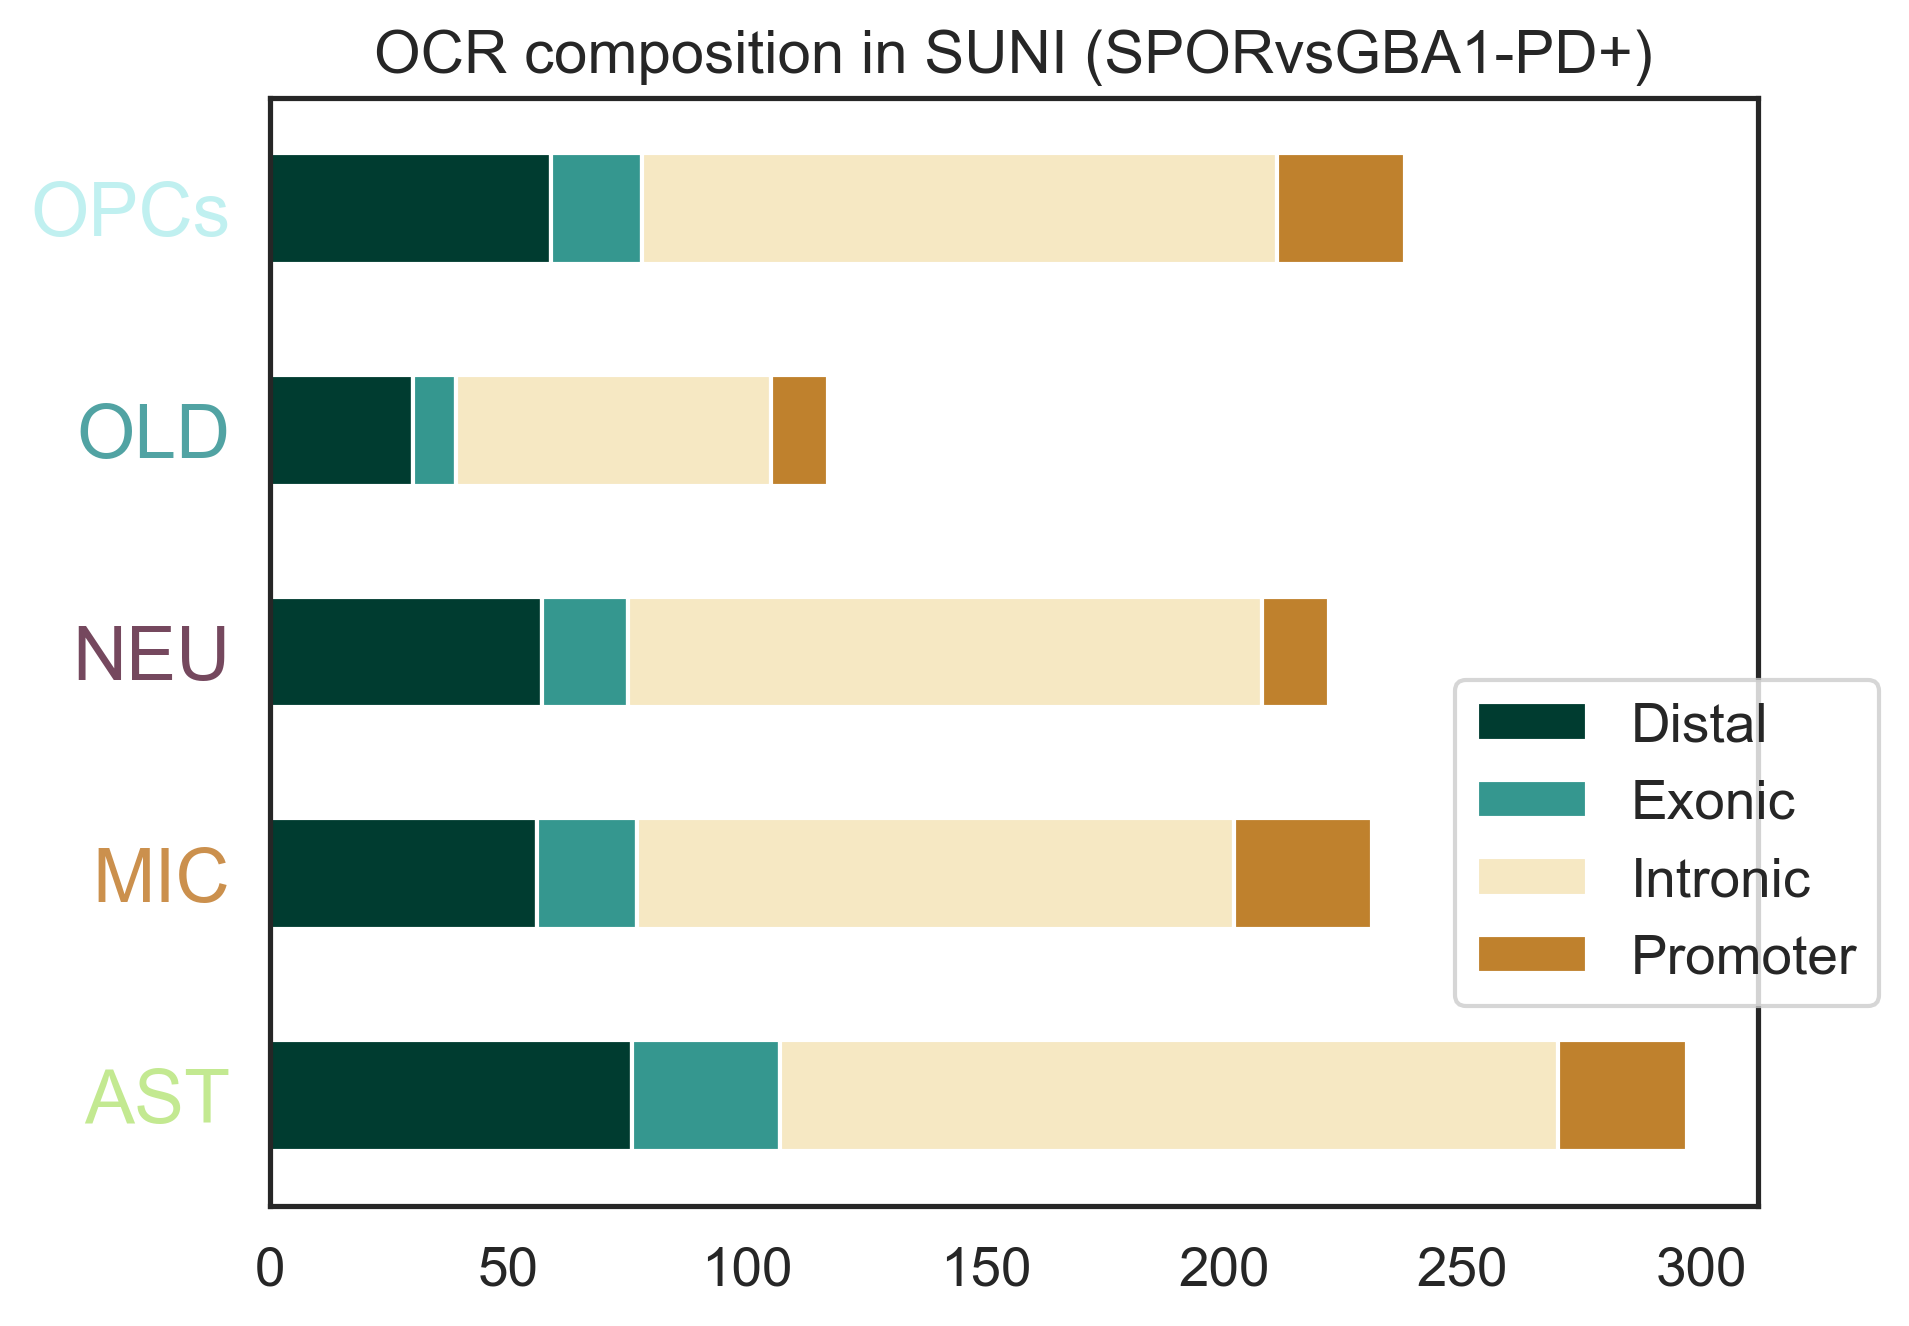

In [19]:
de = res_DE[res_DE.type_reg!="not significant"]


de.comparison.unique()

comp = "SPOR$GBA1-PD+"

# comp = "E4+$E4-"
br="SUNI"
de = de[(de.br ==br)&(de.comparison==comp)]
ff = de.groupby(["ct", "peakType"]).size().unstack()#/de.groupby(["ct", "peakType"]).size().unstack().sum(1).values[:,np.newaxis]
# ff /=100.
ax = ff.plot(kind='barh', stacked=True, color=['#003C30', "#35978F", "#F6E8C3", "#BF812D"])

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    
    x, y = p.get_xy() 
   # ax.annotate(f'{int(height)}%', (x + width/2, y + height*0.5), ha='center')
plt.title("OCR composition in %s (%s)"%(br,comp.replace("$", "vs")))
plt.ylabel("celltype")
for label in (ax.get_yticklabels()):
    print(label)
    txt = label.get_text()#.split("|")[1]

    cond = label.get_text()#.split("|")[0]
    label.set(color=COLORS_CT[cond], label=str(txt), fontsize=18)
ax.set_ylabel("")
ax.legend(bbox_to_anchor=(1.1,0.5))
plt.savefig("./outdir/DE_ocr_spor_gba1_peak_de_composition_%s_%s.svg"%(comp,br), bbox_inches="tight")

In [20]:
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,index,nearestGeneChip,nearestGene,peakType,...,names,-log10(pvals),-log10(qvals),ranks,significant,downreg,type_reg,comparison,br,ct
chr1_3071841_3072341,3658.403093,-0.500838,0.155883,-3.212902,1.314013e-03,0.069740,chr1_3071841_3072341,PRDM16,PRDM16,Intronic,...,chr1_3071841_3072341,2.881400,1.308021,-0.655107,True,True,down,SPOR$GBA1-PD+,SUNI,AST
chr1_3156917_3157417,4855.020060,-0.707060,0.190254,-3.716411,2.020728e-04,0.030705,chr1_3156917_3157417,MIR4251,PRDM16,Intronic,...,chr1_3156917_3157417,3.694492,1.679377,-1.187421,True,True,down,SPOR$GBA1-PD+,SUNI,AST
chr1_3211971_3212471,4912.861015,-0.940199,0.290646,-3.234865,1.217002e-03,0.067149,chr1_3211971_3212471,PRDM16,PRDM16,Intronic,...,chr1_3211971_3212471,2.914709,1.327018,-1.247662,True,True,down,SPOR$GBA1-PD+,SUNI,AST
chr1_5994677_5995177,3796.056781,-0.534447,0.156521,-3.414531,6.389196e-04,0.050617,chr1_5994677_5995177,KCNAB2,NPHP4,Intronic,...,chr1_5994677_5995177,3.194554,1.455037,-0.777639,True,True,down,SPOR$GBA1-PD+,SUNI,AST
chr1_6034661_6035161,3564.912608,-0.561255,0.174910,-3.208815,1.332833e-03,0.069740,chr1_6034661_6035161,KCNAB2,NPHP4,Intronic,...,chr1_6034661_6035161,2.875224,1.308015,-0.734130,True,True,down,SPOR$GBA1-PD+,SUNI,AST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr22_43848674_43849174,1296.596951,-0.824533,0.174856,-4.715494,2.411251e-06,0.002500,chr22_43848674_43849174,SULT4A1,SULT4A1,Intronic,...,chr22_43848674_43849174,5.617758,2.872535,-2.368499,True,True,down,SPOR$GBA1-PD+,SUNI,OLD
chr22_44068203_44068703,1237.898637,-0.782807,0.244933,-3.196007,1.393439e-03,0.077637,chr22_44068203_44068703,PARVB,PARVB,Intronic,...,chr22_44068203_44068703,2.855912,1.303587,-1.020456,True,True,down,SPOR$GBA1-PD+,SUNI,OLD
chr22_45551550_45552050,2877.128375,-0.766236,0.146278,-5.238211,1.621406e-07,0.001514,chr22_45551550_45552050,FBLN1,FBLN1,Intronic,...,chr22_45551550_45552050,6.790108,3.090325,-2.367919,True,True,down,SPOR$GBA1-PD+,SUNI,OLD
chrX_108582142_108582642,8148.249191,0.659005,0.172976,3.809813,1.390720e-04,0.021522,chrX_108582142_108582642,COL4A5,COL4A5,Intronic,...,chrX_108582142_108582642,3.856760,1.870667,1.232779,True,False,up,SPOR$GBA1-PD+,SUNI,OLD


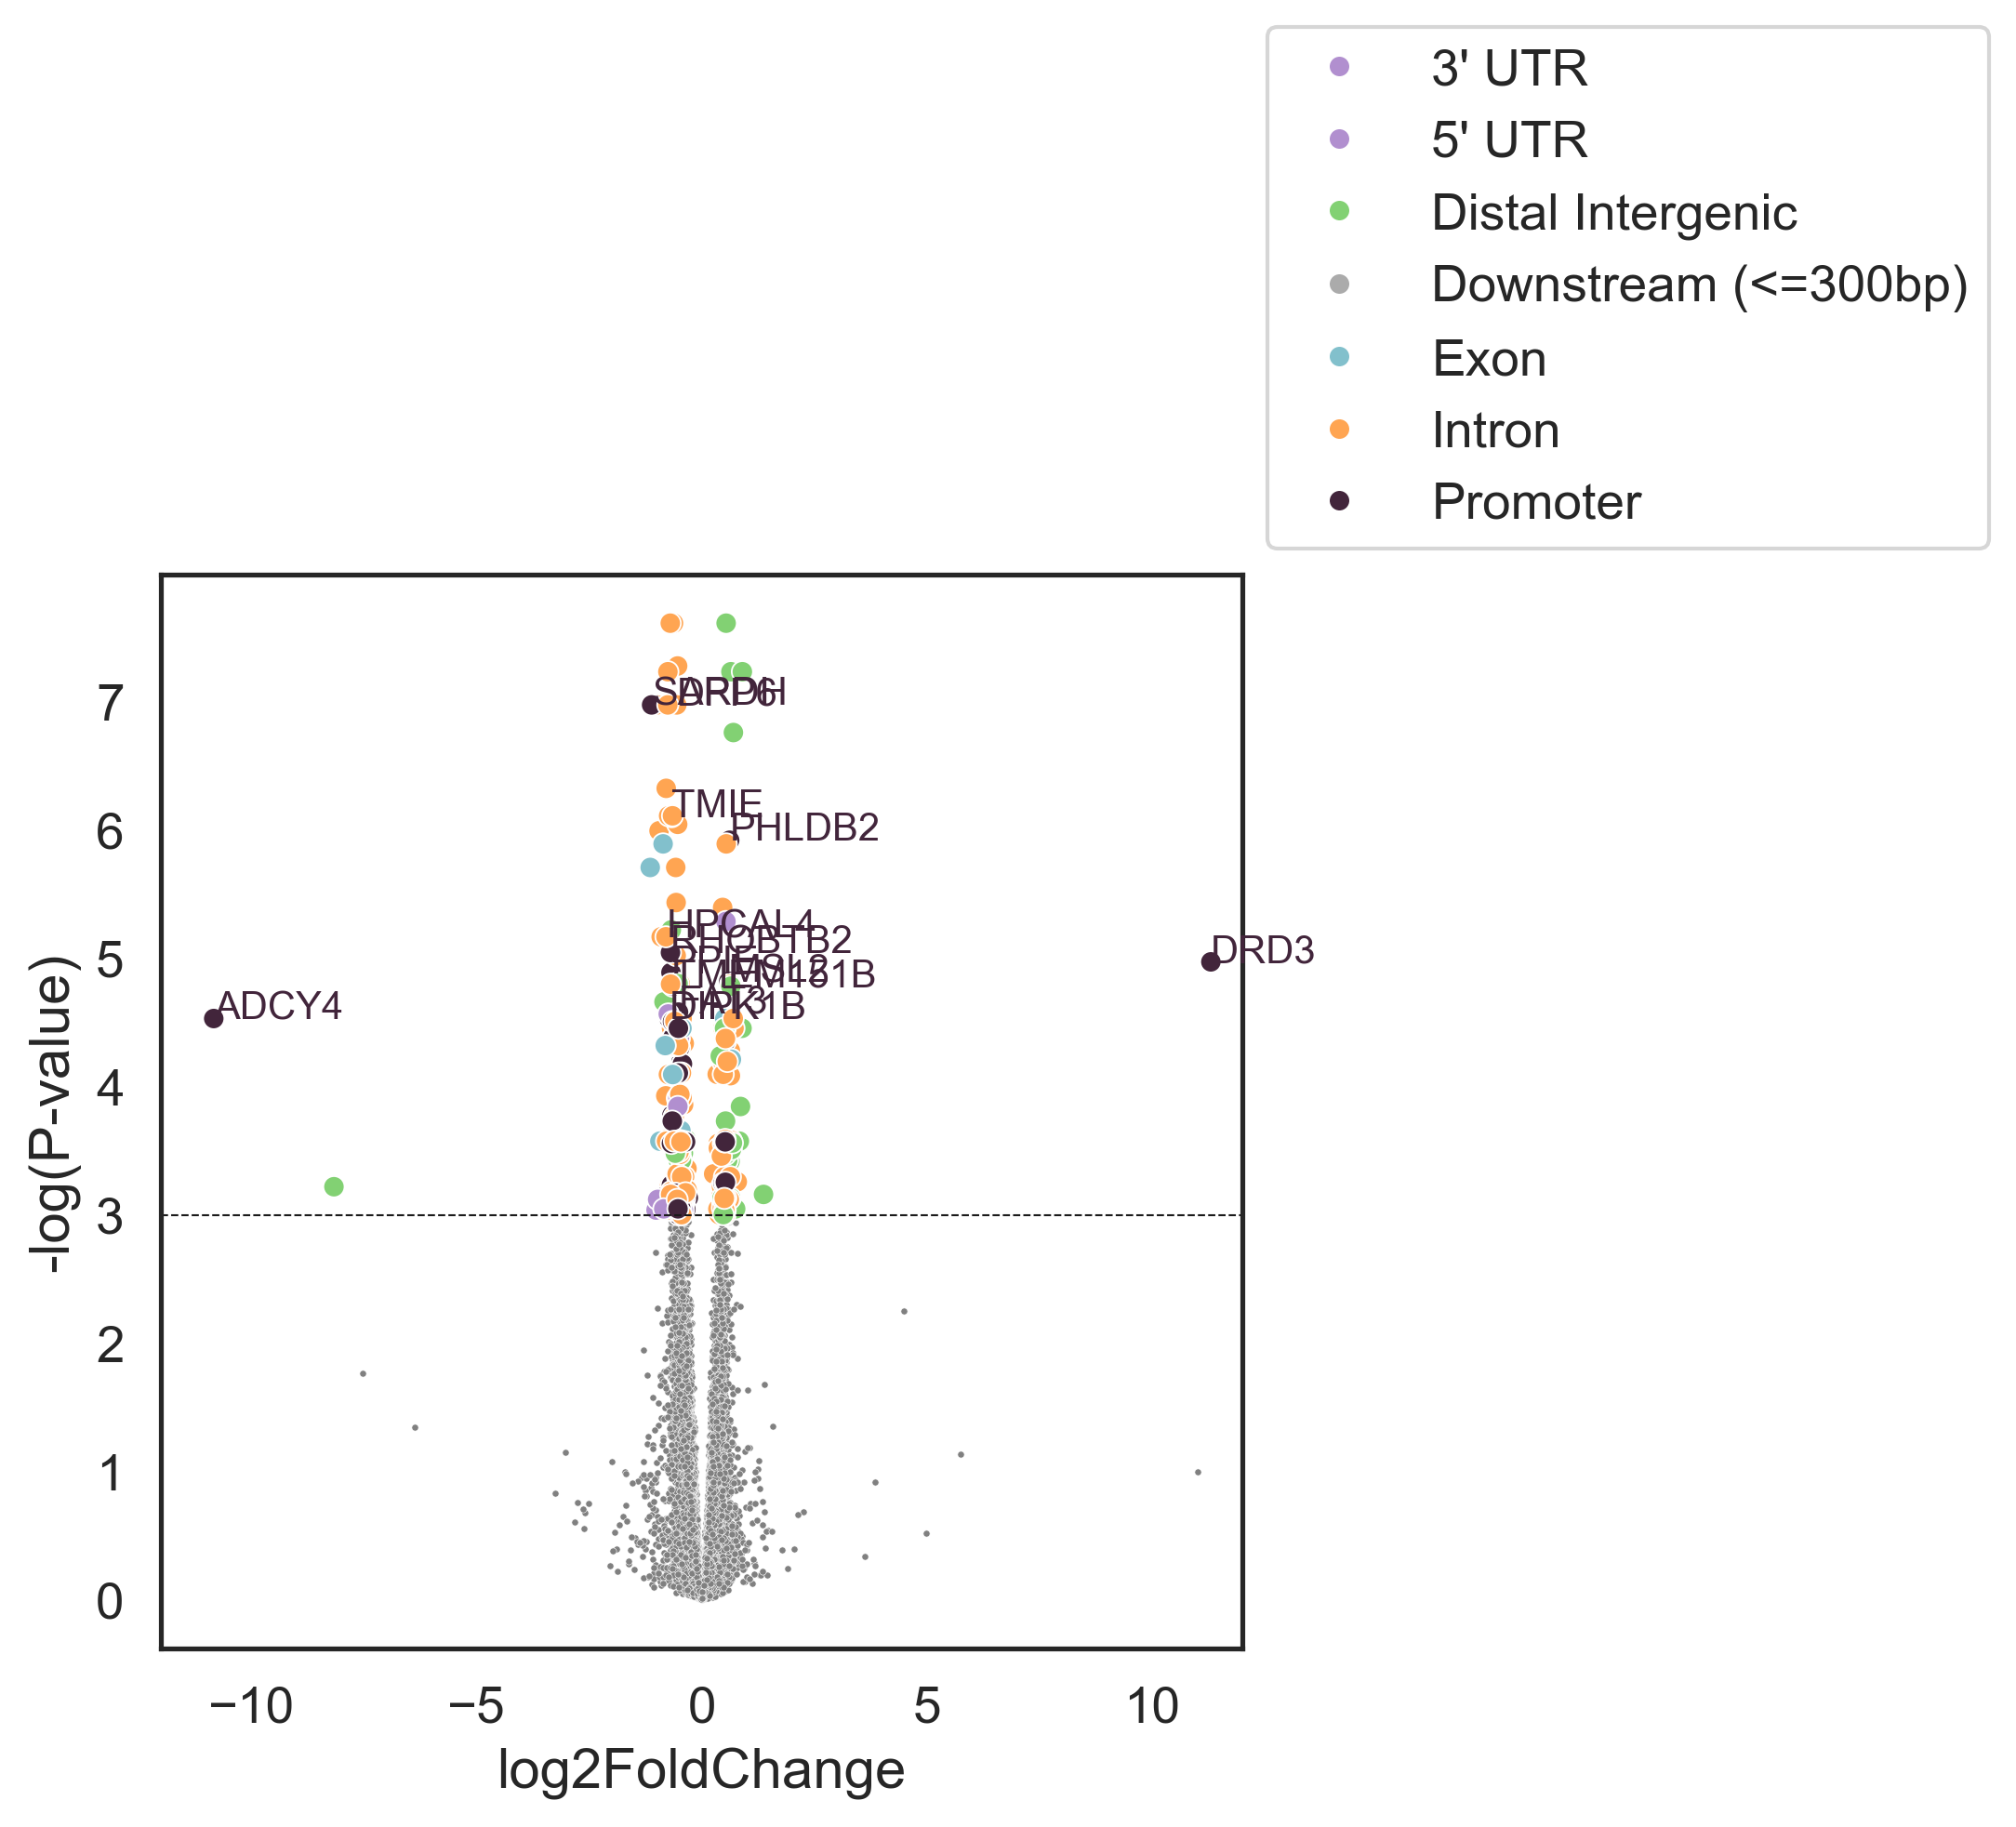

In [21]:
pal = {"3' UTR":"#b18fcf","5' UTR":"#b18fcf","Promoter":"#42253b", "Intron":"#ffa552","Exon":"#82c0cc","Distal Intergenic":"#82d173",  'Downstream (<=300bp)':"#ababab"}

comp = "SPOR$GBA1-PD+"

br="SUNI"
ct = "NEU"

res_DE["-log(P-value)"] = -np.log(res_DE["padj"])
# res_DE["annot"] = res_DE["annotation"].str.split(" \(", expand=True)[0]

toplot = res_DE[(res_DE.br==br)&(res_DE.ct==ct)&(res_DE.comparison==comp)]

fig, ax = plt.subplots(figsize=(5,5))
x="log2FoldChange"
y="-log(P-value)"
sns.scatterplot(data = toplot[(toplot.padj>0.05)], x=x, y=y, color="gray", s=3)
sns.scatterplot(data = toplot[(toplot.padj<=0.05)], x=x, y=y, color="gray", s=30, hue='shortAnnotChip', palette=pal)
ax.axhline(y=-np.log(0.05), c="k", linestyle="--", linewidth=0.5)
# ax.axvline(x=-0.2, c="k", linestyle="--", linewidth=0.5)
# ax.axvline(x=0.2, c="k", linestyle="--", linewidth=0.5)
ax.legend(bbox_to_anchor=(1,1))

texts = []
for i, it in enumerate(toplot[toplot.padj<=0.011].iterrows()):
    if it[1]['shortAnnotChip']=="Promoter":
        text = plt.text(it[1][x], it[1][y], it[1]["nearestGeneChip"], fontsize=10, color=pal[it[1]['shortAnnotChip']])
        texts.append(text)

# Adjust text to avoid overlap
# adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black'))
ax.set_xlim(-12,12)
plt.savefig("outdir/volcano_deconvoluted_DE_gba_spor_%s_%s.svg"%(br,ct))

In [28]:
import gseapy as gp

comp = "SPOR$GBA1-PD+"
br="SUNI"
ct = "AST"

toplot = res_DE[(res_DE.br==br)&(res_DE.ct==ct)&(res_DE.comparison==comp)]

gene_list = toplot.set_index("nearestGeneChip")[["log2FoldChange"]].sort_values("log2FoldChange",ascending=False)
adata.var.index = adata.var.index.astype(str)
adata.obs.index = adata.obs.index.astype(str)
bg = adata.var["nearestGeneChip"].astype(str).unique().tolist()
enr = gp.prerank(rnk=gene_list, # or "./tests/data/gene_list.txt",
                 background=bg,
                 permutation=5000,
                 pheno_pos = "SPOR",
        pheno_neg = "GBA1",
                 gene_sets=['KEGG_2021_Human'],#
                 # gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                )
enr.res2d

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,KEGG_2021_Human__GABAergic synapse,0.642207,2.569571,0.002532,0.326085,0.088,25/62,18.17%,PLCL1;GAD2;PRKCB;GNAI1;GLS;GABRA1;GABRA6;GNAO1...
1,prerank,KEGG_2021_Human__mRNA surveillance pathway,0.720697,2.535127,0.002488,0.219844,0.106,9/36,3.76%,MSI2;DAZAP1;PPP2R2C;PABPC4L;CSTF2T;FIP1L1;PPP2...
2,prerank,KEGG_2021_Human__Platelet activation,0.5919,2.43628,0.004975,0.253855,0.149,19/74,9.07%,TLN1;MAPK14;PRKG1;VWF;PIK3R5;GNAI1;FCGR2A;ITPR...
3,prerank,KEGG_2021_Human__Shigellosis,0.533665,2.384624,0.0,0.224578,0.159,26/132,9.29%,TLN1;GLMN;PFN4;GSK3B;ACTR3B;HK2;CAST;MAPK14;MT...
4,prerank,KEGG_2021_Human__Rap1 signaling pathway,0.508073,2.304376,0.002874,0.228049,0.19,27/133,9.86%,TLN1;EFNA2;PFN4;MAPK14;PDGFC;PRKCB;RAPGEF6;CDH...
...,...,...,...,...,...,...,...,...,...,...
248,prerank,KEGG_2021_Human__Malaria,0.200158,0.646389,0.947368,0.97106,1.0,3/25,6.97%,IL10;GYPC;TLR2
249,prerank,KEGG_2021_Human__Glycolysis / Gluconeogenesis,0.186126,0.634113,0.950704,0.972793,1.0,3/31,8.75%,HK2;PDHA2;LDHB
250,prerank,KEGG_2021_Human__Cholesterol metabolism,-0.195769,-0.601575,0.947748,1.0,1.0,3/25,9.19%,OSBPL5;LRPAP1;LDLR
251,prerank,KEGG_2021_Human__Lysine degradation,-0.182577,-0.599881,0.956007,0.976494,1.0,12/36,29.93%,KMT5C;EHHADH;NSD2;KMT5A;PIPOX;SUV39H1;SETD2;KM...


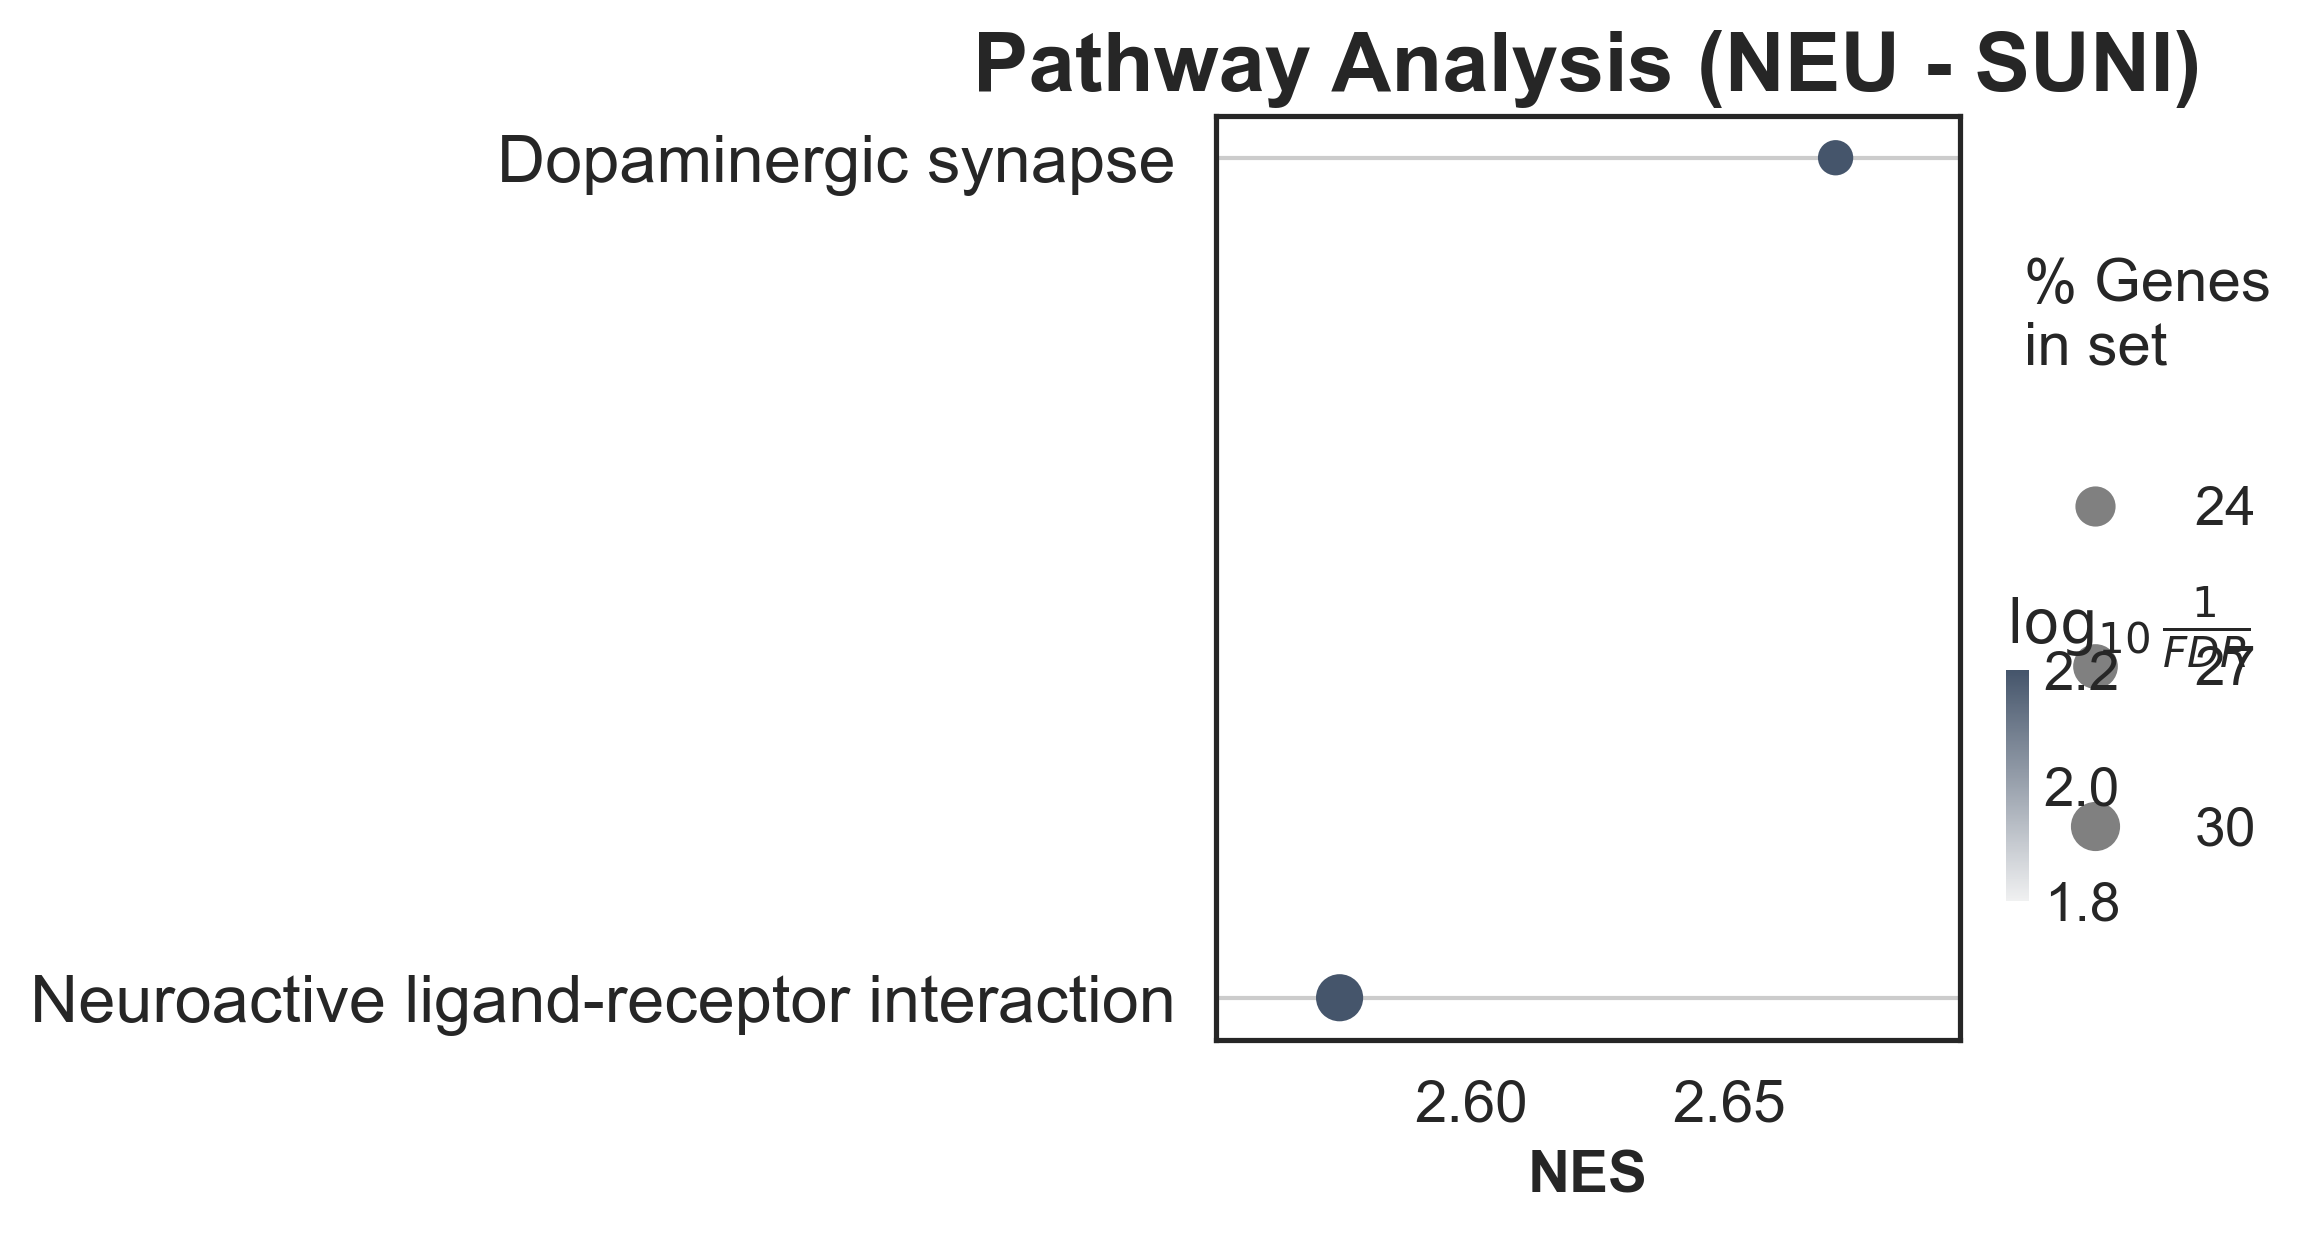

In [25]:
term = enr.res2d.copy()
term.Term = term.Term.str.replace("KEGG_2021_Human__","")
ax = gp.dotplot(term,
             # column="-log(Qvalue)",
                column="FDR q-val",
             title='Pathway Analysis (%s - %s)'%(ct,br),
             cmap=cmap,
              top_term=20,
             size=6, # adjust dot size
             figsize=(4,4), cutoff=0.05, show_ring=False)
plt.savefig("outdir/pathway_deconvoluted_%s_%s.svg"%(br,ct))

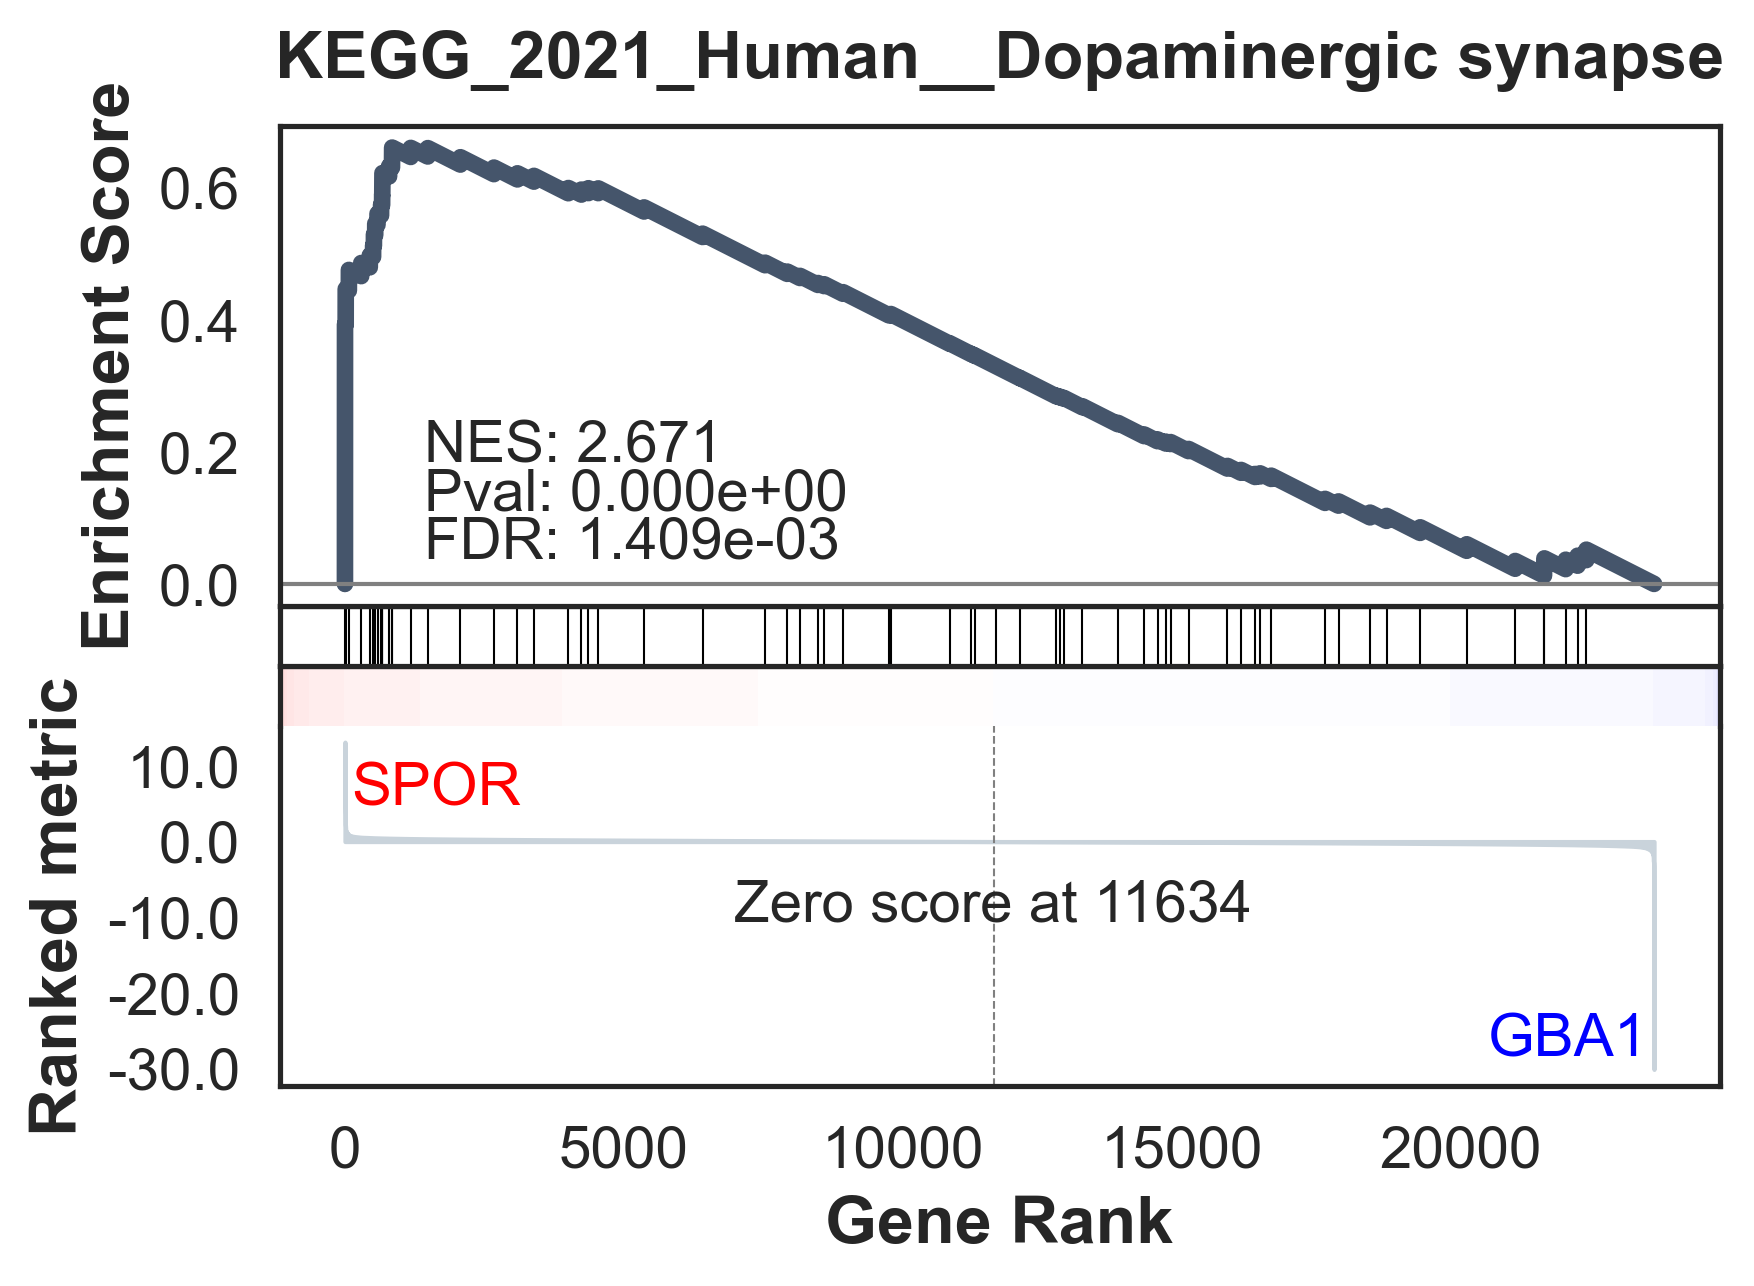

In [26]:
terms = enr.res2d.Term
axs = enr.plot(terms=terms[0], figsize=(6,4), colors="#45556B",
            ) # v1.0.5

In [27]:
list_ = enr.res2d["Lead_genes"][0].split(";")
toplot[(toplot["nearestGeneChip"].isin(list_)) &(toplot.padj<=0.05)]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,index,nearestGeneChip,nearestGene,peakType,...,-log10(pvals),-log10(qvals),ranks,significant,downreg,type_reg,comparison,br,ct,-log(P-value)
chr3_114177979_114178479,44.610384,11.306695,2.560502,4.415812,0.000010,0.006946,chr3_114177979_114178479,DRD3,DRD3,Intronic,...,4.997266,NaN,NaN,False,False,not significant,SPOR$GBA1-PD+,SUNI,NEU,4.969597
chr4_113483110_113483610,6145.001811,0.466744,0.133680,3.491505,0.000480,0.045821,chr4_113483110_113483610,CAMK2D,CAMK2D,Intronic,...,3.318481,1.499359,0.699816,False,False,not significant,SPOR$GBA1-PD+,SUNI,NEU,3.083022
chr16_24101552_24102052,1992.348471,0.570871,0.142344,4.010515,0.000061,0.015101,chr16_24101552_24102052,PRKCB,MIR1273H,Intronic,...,4.217625,1.995679,1.139276,True,False,up,SPOR$GBA1-PD+,SUNI,NEU,4.192972


# pseudo trajectory

In [ ]:
adata.obs["xxx.Braak score"].unique().tolist()

adata.obs["Braak Score"] = adata.obs["xxx.Braak score"].map({"I":1, "II":1,"III":2, "IV":2, "V":3, "VI":3}).astype(float).values
adata.obs["LB Stages"] = adata.obs['xxx.Unified LB Stage'].map({"0. No Lewy bodies":0.,"lV. Neocortical":3.,
                                                     "lll. Brainstem/Limbic":2.,"lla. Brainstem Predominant":1.,
                                                               "llb. Limbic Predominant":2.}).values
adata.obs["Total path"] = adata.obs["Braak Score"].values.astype(float) + adata.obs["LB Stages"]
adata.obs["Total path"] 

In [ ]:

def get_pvalue(x,y):
    _,pval =spearmanr(x,y)
    return pval
ct = "AST"
br = "SUNI"

adata_tmp = adata[(adata.obs.celltype==ct)&(adata.obs.brain_region==br) &(adata.obs.condition.isin(["SPOR", "GBA1-PD+"]))]#, adata.var.peakid.isin(de_.peakid.unique().tolist())]
adata_tmp
ada_df = adata_tmp.to_df()
print(ada_df.shape)
ada_df = ada_df.loc[:,ada_df.astype(float).sum()>0]
print(ada_df.shape)
ada_df['AD path'] = adata_tmp.obs['AD path'].map({"low/no":0.,"moderate/high":1.}).values
ada_df['LB path'] = adata_tmp.obs['PD path'].values
ada_df["condition"] = adata_tmp.obs['condition'].values

d1 = ada_df[ada_df["condition"]=="SPOR"].drop("condition", axis=1)
d2 =  ada_df[ada_df["condition"]=="GBA1-PD+"].drop("condition", axis=1)

met = "spearman"

# d1pval = d1.astype(float).corr(method=get_pvalue)
# d2pval = d2.astype(float).corr(method=get_pvalue)
d1 = d1.astype(float).corr(method=met)
d2 = d2.astype(float).corr(method=met)




d1 = d1.loc[d1.isna().sum()<len(d1),d1.isna().sum()<len(d1)]
cols = [it for it in d1.columns.tolist() if it not in ['AD path', 'LB path']]
d1 = d1.loc[['AD path', 'LB path'],cols]
d1.index = ["SPOR|" + it for it in d1.index.tolist()]

d2 = d2.loc[d2.isna().sum()<len(d2),d2.isna().sum()<len(d2)]
cols = [it for it in d2.columns.tolist() if it not in ['AD path', 'LB path']]
d2 = d2.loc[['AD path', 'LB path'],cols]
d2.index = ["GBA1-PD+|" + it for it in d1.index.tolist()]

tmp = pd.concat([d1,d2])
tmp

tmp = tmp.T

tmp

tmp =np.abs(tmp)
tmp[tmp<0.6] =0
tmp = tmp.loc[tmp.sum(1)>0,:]
tmp
adata_tmp = adata_tmp[:, tmp.index.tolist()]
adata_tmp

In [ ]:
import palantir
import scanpy.external as sce
ct = "NEU"
br = "SUNI"
COLORS_CT = {"NEU":"#75485E","EXC":"#C23E7E", "INH":"#75485E",  "OLD":"#51A3A3","OPCs":"#C0F0F0", "MIC":"#CB904D", "AST":"#C3E991",
           "bulk":"#CCCCCC", # "SPOR":"#F7D7C8",
        "CTRL":"#EBEBEB","SPOR":"#A9E5BB", "GBA1":"#2D1E2F", "LRRK2":"#F7B32B","LRRK2_PD-":"#fce8bf","LRRK2_PD+":"#F7B32B",
             "GBA1-PD+":"#2D1E2F","GBA1_PD-":"#817882",
           "CAUD":"#12323B", "SMTG":"#FE5F55", ##760E44",
            "MDFG":"#FFD6C0", ##C2518B",
             "HIPP":"#F0C20E", "PTMN":"#B4E1FF","SUNI":"#7A9B76", ##96C22B",
            "Male":"#28587B","Female":"#FF715B", }

#[(res_DE.ct==ct) & 
de_ = res_DE[(res_DE.br==br) &( res_DE.significant==True) &( res_DE.comparison.isin(["SPOR$GBA1-PD+"]))]#"SPOR$GBA1-PD+","SPOR$All", "GBA1-PD+$All"
de_

all=[]
for ct in adata.obs.celltype.unique().tolist():
    
    if ct != "bulk":
        tmp = de_[de_.ct==ct]
        adata_tmp = adata[#
            (adata.obs.celltype==ct)&
                   #&
                (adata.obs.brain_region==br) 
                &(adata.obs.condition.isin(["SPOR", "GBA1-PD+", "GBA1_PD+"])),
                 # & (adata.obs["Total path"].isin([1,2,3,4,5,6])),
                # adata.var.peakid.isin(interpeak+de_.peakid.unique().tolist())]
                adata.var.peakid.isin(tmp.peakid.unique().tolist())
                ]
        adata_tmp.obs.reset_index(drop=True, inplace=True)
        adata_tmp.var_names =[ct + "|" + it for it in adata_tmp.var_names.tolist()]
        
        all.append(adata_tmp)
    


adata_tmp = ad.concat(all,axis=1)
adata_tmp


In [ ]:
adata_tmp.obs = all[0].obs.drop(["celltype"], axis=1)

In [ ]:
adata_tmp = adata_tmp[~adata_tmp.obs["Total path"].isna()]

In [ ]:
COLORS_CT

COLORS_CT["SPOR"] = "#87B695"
COLORS_CT["GBA1_PD+"] =COLORS_CT["GBA1-PD+"]

In [ ]:
palette= {"DOWN": "#F6E8C3", "UP":"#003C30"}
norm=plt.Normalize(-2,2)
tt = "UP"
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", [ "#F6E8C3","#5EBDAA",palette[tt]])
sc.pp.pca(adata_tmp)
sc.pp.neighbors(adata_tmp, n_neighbors=10)
sc.tl.umap(adata_tmp)
sc.tl.tsne(adata_tmp)
sce.tl.phate(adata_tmp, k=10,  t="auto")

sc.pl.umap(adata_tmp,color=["condition", "Total path"], s=100, ncols=2, wspace=0.4, 
                                   palette=COLORS_CT, cmap=cmap,
          )#cmap="BrBG"
# sc.pl.tsne(adata_tmp,color=["condition", "AD path", "LB Stage", "Sex"], s=100, ncols=2, wspace=0.4)

sce.pl.phate(adata_tmp,color=["condition", "Total path"], s=100, ncols=2, wspace=0.4,
             palette=COLORS_CT, cmap=cmap,
            )#cmap="BrBG"

In [ ]:
# Run diffusion maps
# adata_tmp.obsm["X_umap"] = adata_tmp.obsm['X_phate']
dm_res = palantir.utils.run_diffusion_maps(adata_tmp, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(adata_tmp)

palantir.plot.plot_diffusion_components(adata_tmp,s=50)
plt.figure(figsize=(20,10))
plt.show()

In [ ]:
# adata_tmp.obsm["X_umap"] = dm_res['EigenVectors'][[1,2]].values

In [ ]:
sc.pl.umap(adata_tmp,color=["condition", "Total path"], s=100, ncols=2, wspace=0.4, 
                                   palette=COLORS_CT,cmap=cmap
          )#cmap="BrBG"

In [ ]:
from scipy.stats import spearmanr, pearsonr
x = dm_res['EigenVectors'][1].values
y = adata_tmp.obs["Total path"].values

x = x[~np.isnan(y)].astype(float)
y = y[~np.isnan(y)].astype(float)
print(spearmanr(x,y))

x = dm_res['EigenVectors'][2].values
y = adata_tmp.obs["condition"].map({"SPOR":1., "GBA1-PD+":0}).astype(float).values

x = x[~np.isnan(y)].astype(float)
y = y[~np.isnan(y)].astype(float)
print(spearmanr(x,y))


jj = adata_tmp.obs[adata_tmp.obs["condition"] == "SPOR"].index.tolist()
x = dm_res['EigenVectors'].loc[jj,:][1].values
y = adata_tmp.obs.loc[jj,"Total path"].values

x = x[~np.isnan(y)].astype(float)
y = y[~np.isnan(y)].astype(float)
print(spearmanr(x,y))


In [ ]:
terminal_states = pd.Series(
  ["GBA1-PD+", "SPOR"],
    index=["28", "2"] #"2441", "2289","2428" #2442 or 2430, 2288
    #18, #2, #28
)
palantir.plot.highlight_cells_on_umap(adata_tmp, terminal_states)
plt.show()##2304

In [ ]:
start_cell ="18"# "2304"
# adata_tmp.obsm["X_umap"] = adata_tmp.obsm["X_phate"]
pr_res = palantir.core.run_palantir(
    adata_tmp, start_cell, num_waypoints=500,knn=15, terminal_states=terminal_states
)

In [ ]:
adata_tmp.obs["Pseudotime"] = adata_tmp.obs["palantir_pseudotime"]
adata_tmp.obs["Diffusion component 2"] = dm_res['EigenVectors'][2].values
sns.set(font_scale=1.5,style="white")
sce.pl.phate(adata_tmp,color=["condition",  "Total path","Pseudotime"], s=200, ncols=3, wspace=0.4,
             palette=COLORS_CT, cmap=cmap, save="phate_pseudotime_palantir.svg")

sc.pl.umap(adata_tmp,color=["condition",  "Total path","Pseudotime"], s=100, ncols=3, wspace=0.4, 
                                   palette=COLORS_CT,save="umap_pseudotime_palantir.svg",
          cmap=cmap)

In [ ]:

palantir.plot.plot_palantir_results(adata_tmp, s=10)
plt.show()

In [ ]:
adata_tmp.obsm['palantir_fate_probabilities']#.obs#["palantir_pseudotime"]

if True:
#     q = 1e-2
#     eps = 1e-2
    masks_key = "branch_masks"
    fate_probs = adata_tmp.obsm['palantir_fate_probabilities'].values
    fate_names = adata_tmp.obsm['palantir_fate_probabilities'].columns.tolist()
#     pseudotime = adata_tmp.obs["palantir_pseudotime"].values

#     idx = np.argsort(pseudotime)
#     sorted_fate_probs = fate_probs[idx, :]
#     prob_thresholds = np.empty_like(fate_probs)
#     n = fate_probs.shape[0]

#     # step = n // PSEUDOTIME_RES
#     step=0
#     nsteps =1 #n // step
#     for i in range(nsteps):
#         l, r = i * step, (i + 1) * step
#         mprob = np.quantile(sorted_fate_probs[:, :], 1 - q, axis=0)
#         prob_thresholds[:, :] = mprob[None, :]
#     mprob = np.quantile(sorted_fate_probs, 1 - q, axis=0)
#     prob_thresholds[r:, :] = mprob[None, :]
#     prob_thresholds = np.maximum.accumulate(prob_thresholds, axis=0)

    masks = np.empty_like(fate_probs).astype(bool)
    print(masks.shape)
    masks[:, 0] = adata_tmp.obs["condition"] =="SPOR"
    masks[:, 1] = adata_tmp.obs["condition"] !="SPOR"
    print(pd.DataFrame(masks, columns=fate_names, index=adata_tmp.obs_names))
    #if save_as_df:
    adata_tmp.obsm[masks_key] = pd.DataFrame(masks, columns=fate_names, index=adata_tmp.obs_names)

In [ ]:
var = "Braak Score" #"Total path"
adata_tmp.obs["CI"] = adata_tmp.obs["Cognitive Imp"].map({"no":0, "yes":1}).astype(float)
ax = sns.regplot(data=adata_tmp.obs, x="palantir_pseudotime", y=var, color="#003C30")


x = adata_tmp.obs["palantir_pseudotime"].values
y = adata_tmp.obs[var].values

x = x[~np.isnan(y)].astype(float)
y = y[~np.isnan(y)].astype(float)
s, p = spearmanr(x,y)
ax.set_title("Rho %s, Pvalue=%s"%(str(np.round(s,2)), str(np.round(p, 3))))
ax.set_xlabel("Pseudotime")
plt.savefig(outdir + "/palentir_pseudotime_%s.svg"%var)

In [ ]:
outdir

In [ ]:
var = "Total path"
adata_tmp.obs["CI"] = adata_tmp.obs["Cognitive Imp"].map({"no":0, "yes":1}).astype(float)
ax = sns.regplot(data=adata_tmp.obs, x="palantir_pseudotime", y=var, color="#003C30")


x = adata_tmp.obs["palantir_pseudotime"].values
y = adata_tmp.obs[var].values

x = x[~np.isnan(y)].astype(float)
y = y[~np.isnan(y)].astype(float)
s, p = spearmanr(x,y)
ax.set_title("Rho %s, Pvalue=%s"%(str(np.round(s,3)), str(np.round(p, 3))))
ax.set_xlabel("Pseudotime")
plt.savefig(outdir + "/palentir_pseudotime_%s.svg"%var)

In [ ]:
var = "LB Stages"
adata_tmp.obs["CI"] = adata_tmp.obs["Cognitive Imp"].map({"no":0, "yes":1}).astype(float)
ax = sns.regplot(data=adata_tmp.obs, x="palantir_pseudotime", y=var, color="#003C30")


x = adata_tmp.obs["palantir_pseudotime"].values
y = adata_tmp.obs[var].values

x = x[~np.isnan(y)].astype(float)
y = y[~np.isnan(y)].astype(float)
s, p = spearmanr(x,y)
ax.set_title("Rho %s, Pvalue=%s"%(str(np.round(s,2)), str(np.round(p, 3))))
ax.set_xlabel("Pseudotime")
plt.savefig(outdir + "/palentir_pseudotime_%s.svg"%var)

In [ ]:
var = "ApoE_4" #"Total path"
adata_tmp.obs["CI"] = adata_tmp.obs["Cognitive Imp"].map({"no":0, "yes":1}).astype(float)
adata_tmp.obs["sex"] = adata_tmp.obs["Sex"].map({"Male":0, "Female":1}).astype(float)


# x = adata_tmp.obs["palantir_pseudotime"].values
cond = "SPOR"
cond="GBA1-PD+"
adata_tmp.obs['palantir_fate_probabilities_SPOR'] = adata_tmp.obsm['palantir_fate_probabilities']["SPOR"].values
adata_tmp.obs['palantir_fate_probabilities_GBA1-PD+'] = adata_tmp.obsm['palantir_fate_probabilities']["GBA1-PD+"].values
x = adata_tmp.obsm['palantir_fate_probabilities'][cond].values
y = adata_tmp.obs[var].values
ax = sns.regplot(data=adata_tmp.obs, x="palantir_fate_probabilities_%s"%cond, y=var, color="#003C30")

x = x[~np.isnan(y)].astype(float)
y = y[~np.isnan(y)].astype(float)
s, p = spearmanr(x,y)
ax.set_title("Rho %s, Pvalue=%s"%(str(np.round(s,2)), str(np.round(p, 3))))
# ax.set_xlabel("Pseudotime")
plt.savefig(outdir + "/palentir_spor_fate_%s_%s.svg"%(var,cond))

In [ ]:
def plot_branch_selection(
    ad: sc.AnnData,
    pseudo_time_key = "palantir_pseudotime",
    fate_prob_key = "palantir_fate_probabilities",
    masks_key= "branch_masks",
    fates = None,
    embedding_basis = "X_umap",
    figsize = (15, 5),
    **kwargs,
):
    if pseudo_time_key not in ad.obs:
        raise KeyError(f"{pseudo_time_key} not found in ad.obs")

    fate_probs, fate_probs_names = palantir.validation._validate_obsm_key(ad, fate_prob_key)
    fate_mask, fate_mask_names = palantir.validation._validate_obsm_key(ad, masks_key)

    if embedding_basis not in ad.obsm:
        raise KeyError(f"{embedding_basis} not found in ad.obsm")

    fate_names = set(fate_probs_names).intersection(fate_mask_names)
    if len(fate_names) == 0:
        raise ValueError(
            f"No agreeing fate names found for .obsm['{fate_prob_key}'] and .obsm['{masks_key}']."
        )
    n_fates = len(fate_names)
    if n_fates < len(fate_probs_names) or n_fates < len(fate_probs_names):
        warnings.warn(
            f"Found only {n_fates} fates in the intersection of "
            f"{len(fate_probs_names)} fate-probability fates in .obsm['{fate_prob_key}'] fates) "
            f"and {len(fate_mask_names)} fate-mask fates in .obsm['{masks_key}']."
        )
    if isinstance(fates, str):
        fates = [fates]
    elif fates is None:
        fates = fate_names
    else:
        for b in fates:
            if b not in fate_names:
                raise (
                    f"Specified fate name '{b}' is not in the available set of "
                    + ", ".join(fate_names)
                )

    pt = ad.obs[pseudo_time_key]
    umap = ad.obsm[embedding_basis]

    figsize = figsize[0], figsize[1] * len(fates)
    fig, axes = plt.subplots(len(fates), 2, figsize=figsize, width_ratios=[2, 1])

    for i, fate in enumerate(fates):
        print(fate)
        if fate == "SPOR":
            no_fate = "GBA1-PD+"
        elif fate == "GBA1-PD+":
            no_fate="SPOR"
        if axes.ndim == 1:
            ax1, ax2 = axes
        else:
            ax1 = axes[i, 0]
            ax2 = axes[i, 1]
        mask = fate_mask[fate].astype(bool)

        # plot cells along pseudotime
        ax1.scatter(
            pt[~mask],
            fate_probs.loc[~mask, fate],
            c=COLORS_CT[no_fate],
            label=no_fate,
            **kwargs,
        )
        ax1.scatter(
            pt[mask],
            fate_probs.loc[mask, fate],
            c=COLORS_CT[fate],
            label=fate,
            **kwargs,
        )
        ax1.set_title(f"Branch: {fate}")
        ax1.set_xlabel("Pseudotime")
        ax1.set_ylabel(f"{fate}-Fate Probability")
        ax1.legend()

        # plot UMAP
        ax2.scatter(
            umap[~mask, 0],
            umap[~mask, 1],
            c=COLORS_CT[no_fate],
            label=no_fate,
            **kwargs,
        )
        ax2.scatter(
            umap[mask, 0],
            umap[mask, 1],
            c=COLORS_CT[fate],
            label=fate,
            **kwargs,
        )
        ax2.set_title(f"Branch: {fate}")
        ax2.axis("off")

    plt.tight_layout()
    return fig


ax = plot_branch_selection(adata_tmp)
plt.savefig(outdir + "/palentir_trajectory_AST.svg")
plt.show()

In [ ]:
adata_tmp.var["ct"] = adata_tmp.var.index.tolist()
adata_tmp.var["ct"] = adata_tmp.var["ct"].str.split("|", expand=True)[0]
adata_tmp.var

In [ ]:
df__ = adata_tmp.to_df()

def get_pvalue(x,y):
    _,pval =spearmanr(x,y)
    return pval
df__["pseudotime_GBA1-PD+"] = adata_tmp.obs['palantir_fate_probabilities_GBA1-PD+']
mat_ = df__.corr(method="spearman").loc[["pseudotime_GBA1-PD+"],:].iloc[:,:-1]

mat_= mat_.T
mat_["genes"] = adata_tmp.var['nearestGeneChip'].tolist()
mat_

# np.where(np.abs(mat_)==np.abs(mat_).max())

mat_#.sort_values("pseudotime_GBA1-PD+")[:10].index.tolist()
mat_p = df__.corr(method=get_pvalue).loc[["pseudotime_GBA1-PD+"],:].iloc[:,:-1]
# mat_p.columns = adata_tmp.var['nearestGeneChip'].tolist()
mat_p= mat_p.T
mat_p


In [ ]:
mat_p.columns = ["pseudotime_GBA1-PD+_pvalue"]
mat_ = mat_.join(mat_p)
mat_

In [ ]:
adata_tmp.var["end"] = adata_tmp.var["peakid"].str.split("_",expand=True)[2]
adata_tmp.var["chrm"] = adata_tmp.var["peakid"].str.split("_",expand=True)[0]
adata_tmp.var["Strand"] = "."

In [ ]:
adata.var["end"] = adata.var["peakid"].str.split("_",expand=True)[2]
adata.var["chrm"] = adata.var["peakid"].str.split("_",expand=True)[0]
adata.var["Strand"] = "."
adata.var[["peakid","chrm", "start", "end", "Strand"]].to_csv("/remote/home/eloiseb/data/ATAC-seq_2024/background_homer.tsv",
                                                              sep="\t", index=None)

In [ ]:
df__ = adata_tmp.to_df()

df__["pseudotime_SPOR"] = adata_tmp.obs['palantir_fate_probabilities_SPOR']
mat_s = df__.corr().loc[["pseudotime_SPOR"],:].iloc[:,:-1]
# mat_s.columns = adata_tmp.var['nearestGeneChip'].tolist()
mat_s= mat_s.T
mat_s
mat_ps = df__.corr(method=get_pvalue).loc[["pseudotime_SPOR"],:].iloc[:,:-1]
# mat_ps.columns = adata_tmp.var['nearestGeneChip'].tolist()
mat_ps= mat_ps.T
mat_ps
mat_ps.columns = ["pseudotime_SPOR_pvalue"]
mat_s = mat_s.join(mat_ps)
mat_s

mat_ =mat_.join(mat_s)

mat_["ct"] = adata_tmp.var["ct"].tolist()
mat_

In [ ]:
from statsmodels.stats.multitest import fdrcorrection
_,mat_["pseudotime_GBA1-PD+_pval_adj"] = fdrcorrection(mat_["pseudotime_GBA1-PD+_pvalue"])
_,mat_["pseudotime_SPOR_pval_adj"] = fdrcorrection(mat_["pseudotime_SPOR_pvalue"])
mat_["-log(pseudotime_GBA1-PD+_qvalue)"]= -np.log2(mat_["pseudotime_GBA1-PD+_pval_adj"])
mat_["-log(pseudotime_SPOR_qvalue)"]= -np.log2(mat_["pseudotime_SPOR_pval_adj"])

In [ ]:
import mellon
def plot_trajectory(
    ad,
    branch,
    ax = None,
    pseudo_time_key= "palantir_pseudotime",
    masks_key = "branch_masks",
    embedding_basis = "X_umap",
    cell_color = "branch_selection",
    smoothness = 1.0,
    n_arrows = 5,
    arrowprops = dict(),
    scanpy_kwargs = dict(),
    figsize = (5, 5),
    color_selected=palantir.config.SELECTED_COLOR,
    color_deselected=palantir.config.DESELECTED_COLOR,
    **kwargs,
    ):
    if pseudo_time_key not in ad.obs:
        raise KeyError(f"{pseudo_time_key} not found in ad.obs")

    fate_mask, fate_mask_names = palantir.validation._validate_obsm_key(ad, masks_key)

    if embedding_basis not in ad.obsm:
        raise KeyError(f"{embedding_basis} not found in ad.obsm")

    if branch not in fate_mask_names:
        raise (
            f"Specified branch name '{branch}' is not in the available set of "
            + ", ".join(fate_mask_names)
        )

    default_kwargs = {"color": "black"}
    default_kwargs.update(kwargs)

    pt = ad.obs[pseudo_time_key]
    umap = ad.obsm[embedding_basis]

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=figsize)

    mask = fate_mask[branch].astype(bool)

    pseudotime = pt[mask]
    pseudotime_grid = np.linspace(np.min(pseudotime), np.max(pseudotime), 200)
    ls = (
        smoothness
        * np.sqrt(np.sum((np.max(umap, axis=0) - np.min(umap, axis=0)) ** 2))
        / 20
    )
    umap_est = mellon.FunctionEstimator(ls=ls, sigma=ls, n_landmarks=50)
    umap_trajectory = umap_est.fit_predict(pseudotime, umap[mask, :], pseudotime_grid)

    # plot UMAP
    if cell_color == "branch_selection":
        ax.scatter(
            umap[~mask, 0],
            umap[~mask, 1],
            c=color_deselected,
            label="Other Cells",
        )
        ax.scatter(
            umap[mask, 0],
            umap[mask, 1],
            c=color_selected,
            label="Selected Cells",
        )
    elif cell_color is not None:
        b = embedding_basis[2:] if embedding_basis.startswith("X_") else embedding_basis
        sc.pl.embedding(ad, b, color=cell_color, ax=ax, show=False, **scanpy_kwargs)

    # plot trajectory
    palantir.plot._plot_arrows(
        umap_trajectory[:, 0],
        umap_trajectory[:, 1],
        n=n_arrows,
        ax=ax,
        arrowprops=arrowprops,
        **default_kwargs,
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Branch: {branch}")
    ax.axis("off")

    return ax


ax = plot_trajectory(adata_tmp, "SPOR", color_selected=COLORS_CT["SPOR"], color_deselected=COLORS_CT["GBA1-PD+"])

plt.savefig(outdir + "/trjectory_umap_spor.svg")
plot_trajectory(adata_tmp, "GBA1-PD+", color_selected=COLORS_CT["GBA1-PD+"], color_deselected=COLORS_CT["SPOR"])
plt.savefig(outdir + "/trjectory_umap_gba1pd.svg")

In [ ]:
gene_trends = palantir.presults.compute_gene_trends(adata_tmp)


In [ ]:
# more_genes = adata_tmp.var_names.tolist()
# communities = palantir.presults.cluster_gene_trends(adata_tmp, "SPOR", more_genes)#,  resolution=)
# communities
# communities = palantir.presults.cluster_gene_trends(adata_tmp, "GBA1_PD+", more_genes)#, resolution=0.2)
# communities

In [ ]:
dfada = adata_tmp[:,(adata_tmp.var["shortAnnotChip"]=="Promoter")].to_df()
dfada["palantir_pseudotime"] =adata_tmp.obs[ 'palantir_pseudotime'].values
mat = dfada.corr()
mat

In [ ]:
# genes = adata_tmp.var[(adata_tmp.var["gene_trends_clusters"]=="2") & (adata_tmp.var["shortAnnotChip"]=="Promoter")].index.tolist()
# palantir.plot.plot_gene_trends(adata_tmp, genes)
# plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
def plot_gene_trend_clusters(
    data,
    selected_color=palantir.config.SELECTED_COLOR,
    deselected_color=palantir.config.DESELECTED_COLOR,
    branch_name = "",
    clusters = None,
    gene_trend_key = "gene_trends",
    ) -> plt.Figure:

    if isinstance(data, sc.AnnData):
        if gene_trend_key is None:
            raise KeyError(
                "Must provide a gene_trend_key when data is an AnnData object."
            )

        trends, pseudotimes = palantir.validation._validate_varm_key(
            data, gene_trend_key + "_" + branch_name
        )

        if clusters is None:
            clusters = gene_trend_key + "_clusters"
        if isinstance(clusters, str):
            clusters = data.var[clusters]
    else:
        trends = data

    trends = pd.DataFrame(
        StandardScaler().fit_transform(np.asarray(trends.values).T).T,
        index=trends.index,
        columns=trends.columns.astype(float),
    )

    # Obtain unique clusters and prepare figure
    cluster_labels = (
        clusters.cat.categories
        if pd.api.types.is_categorical_dtype(clusters)
        else set(clusters)
    )
    n_rows = int(np.ceil(len(cluster_labels) / 3))
    fig = plt.figure(figsize=[5.5 * 3, 2.5 * n_rows])

    # Plot each cluster
    for i, c in enumerate(cluster_labels):
        ax = fig.add_subplot(n_rows, 3, i + 1)
        cluster_trends = trends.loc[clusters.index[clusters == c], :]
        means = cluster_trends.mean()
        std = cluster_trends.std()

        ax.plot(
            cluster_trends.columns,
            cluster_trends.T,
            linewidth=0.5,
            color=deselected_color,
        )
        ax.plot(means.index, means, color=selected_color)
        ax.plot(
            means.index,
            means - std,
            linestyle="--",
            color=selected_color,
            linewidth=0.75,
        )
        ax.plot(
            means.index,
            means + std,
            linestyle="--",
            color=selected_color,
            linewidth=0.75,
        )

        ax.set_title(f"Cluster {c}", fontsize=12)
        ax.tick_params("both", length=2, width=1, which="major")
        ax.tick_params(axis="both", which="major", labelsize=8, direction="in")
        ax.set_xticklabels([])

    return fig

adata_tmp.X = adata_tmp.X.astype(float)
print(adata_tmp.X)

it = "GBA1-PD+"
not_it = "SPOR"
plot_gene_trend_clusters(adata_tmp, branch_name="SPOR", selected_color=COLORS_CT[it], deselected_color="#bababa")
plt.show()

plot_gene_trend_clusters(adata_tmp, branch_name=it, selected_color=COLORS_CT[it], deselected_color="#bababa")
plt.show()

In [ ]:
tmp = res_DE[(res_DE.comparison == "SPOR$GBA1-PD+")&(res_DE["type_reg"] !="not significant")].groupby("br").size()
print(tmp/tmp.sum())

In [ ]:
res_DE.comparison.unique()

# GBA1 versus SPOR versus ALL

In [ ]:
def combine_hex_values(d):
  d_items = sorted(d.items())
  tot_weight = sum(d.values())
  red = int(sum([int(k[:2], 16)*v for k, v in d_items])/tot_weight)
  green = int(sum([int(k[2:4], 16)*v for k, v in d_items])/tot_weight)
  blue = int(sum([int(k[4:6], 16)*v for k, v in d_items])/tot_weight)
  zpad = lambda x: x if len(x)==2 else '0' + x
  return zpad(hex(red)[2:]) + zpad(hex(green)[2:]) + zpad(hex(blue)[2:])


br="SUNI"
ct="AST"
tmp = res_DE[(res_DE.ct==ct) & (res_DE.br==br)&(res_DE.type_reg!="not significant")]
comp1 = tmp[tmp.comparison=="SPOR$GBA1-PD+"]
comp2= tmp[tmp.comparison=="SPOR$All"]
comp3 = tmp[tmp.comparison=="GBA1-PD+$All"]
palette={"GBA1-PD+vsAll":"#2D1E2F",  "SPORvsAll":"#AB4283","SPORvsGBA1-PD+":"#ababab"}
from matplotlib_venn import venn3
set1 = set(comp1.peakid.tolist())
set2=set(comp2.peakid.tolist())
set3=set(comp3.peakid.tolist())
v = venn3(subsets=[set1,set2,set3],
                 set_labels = ("SPORvsGBA1-PD+","SPORvsAll", "GBA1-PD+vsAll"))
v.get_patch_by_id('100').set_color(palette["SPORvsGBA1-PD+"])
v.get_patch_by_id('100').set_edgecolor('none')
v.get_patch_by_id('010').set_color(palette["SPORvsAll"])
v.get_patch_by_id('010').set_edgecolor('none')
v.get_patch_by_id('001').set_color(palette["GBA1-PD+vsAll"])
v.get_patch_by_id('001').set_edgecolor('none')

v110 = combine_hex_values({"ababab": 0.5, "AB4283": 0.5})
print(v110)
v.get_patch_by_id('110').set_color("#%s"%v110)
v.get_patch_by_id('110').set_edgecolor('none')

v101 = combine_hex_values({"ababab": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('101').set_color("#%s"%v101)
v.get_patch_by_id('101').set_edgecolor('none')

v011 = combine_hex_values({"AB4283": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('011').set_color("#%s"%v011)
v.get_patch_by_id('011').set_edgecolor('none')
plt.title("Number of OCR DE in %s (%s)"%(ct,br))

inter = [it for it in list(set1) if it in list(set2) if it in list(set3)]
print(len(inter))
print(tmp[tmp.peakid.isin(inter)]["nearestGeneChip"].unique())
# c.get_patch_by_id('11').set_edgecolor('none')
# c.get_patch_by_id('11').set_alpha(0.4)
plt.savefig("./outdir_plot_res/Venn_OCR__%s_%s"%(ct,br)+ ".svg", bbox_inches="tight")
plt.show()

In [ ]:
tmp[tmp.peakid.isin(inter)].nearestGeneChip.unique().tolist()

In [ ]:
import scanpy as sc
COLORS_CT = {"NEU":"#75485E","EXC":"#C23E7E", "INH":"#75485E",  "OLD":"#51A3A3","OPCs":"#C0F0F0", "MIC":"#CB904D", "AST":"#C3E991",
           "bulk":"#CCCCCC", # "SPOR":"#F7D7C8",
        "CTRL":"#EBEBEB","SPOR":"#AB4283", "GBA1":"#2D1E2F", "LRRK2":"#F7B32B","LRRK2-PD-":"#fce8bf","LRRK2-PD+":"#F7B32B",
             "GBA1-PD+":"#2D1E2F","GBA1-PD-":"#817882",
           "CAUD":"#12323B", "SMTG":"#FE5F55", ##760E44",
            "MDFG":"#FFD6C0", ##C2518B",
             "HIPP":"#F0C20E", "PTMN":"#B4E1FF","SUNI":"#7A9B76", ##96C22B",
            "Male":"#28587B","Female":"#FF715B", }
tmp_ad = adata[:, adata.var.peakid.isin(inter)]
tmp_ad = tmp_ad[(tmp_ad.obs.brain_region==br)&(tmp_ad.obs.celltype==ct)&(tmp_ad.obs.condition.isin(["GBA1-PD+","SPOR","LRRK2-PD+"])) ,:]
sc.pp.neighbors(tmp_ad,n_neighbors=10)
sc.pp.pca(tmp_ad)
sc.tl.umap(tmp_ad)
sc.tl.tsne(tmp_ad)
# sc.pl.pca(tmp_ad, color="condition",components="2,1",palette=COLORS_CT, s=100)
# sc.pl.pca(tmp_ad, color="condition",components="1,4",palette=COLORS_CT, s=100)
# sc.pl.umap(tmp_ad, color="condition",palette=COLORS_CT, s=50)
# sc.pl.tsne(tmp_ad, color="condition",palette=COLORS_CT, s=50)


from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(tmp_ad.X.astype(float))
tmp_ad.obs["PCA1"] =X_pca[:,0]
tmp_ad.obs["PCA2"] =X_pca[:,1]
sns.scatterplot(tmp_ad.obs, x='PCA1', y='PCA2', hue="condition",palette=COLORS_CT)#,labels={'0': 'LDA 1', '1': 'LDA 2'})
plt.title(ct)
plt.savefig("./outdir_plot_res/PCA_OCR__%s_%s"%(ct,br)+ ".svg", bbox_inches="tight")
plt.show()

